### ANOVA results

Loaded 972 units


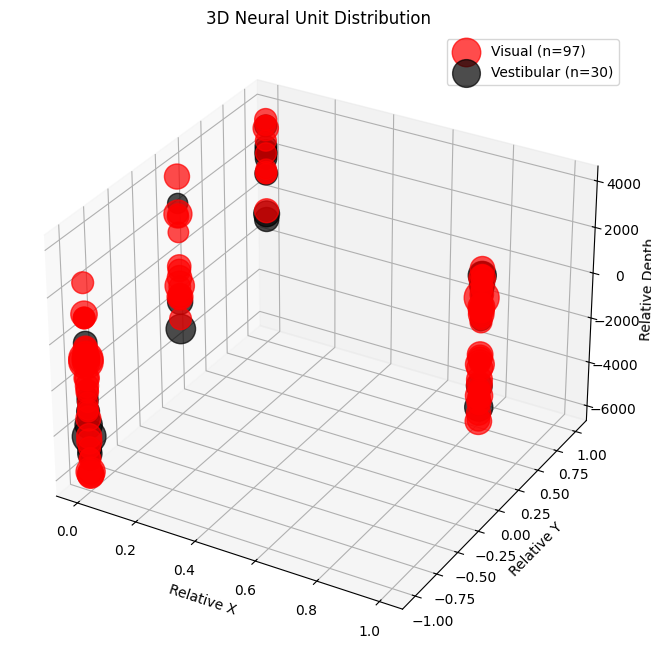


Summary:
Non-responsive: 477 units (49.1%)
Combined: 368 units (37.9%)
Visual: 97 units (10.0%)
Vestibular: 30 units (3.1%)


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load data
df = pd.read_csv(r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMPtuning_neuralfeatures\zarya_pooled_neural_features_tuning.csv')

print(f"Loaded {len(df)} units")

# Categorize responses based on your mapping:
# 1.0 = vestibular, 2.0 = visual, 3.0 = combined
def categorize_response(row):
    ves_selective = row['ves_selective'] == 1  
    vis_selective = row['vis_selective'] == 1  
    comb_selective = row['comb_selective'] == 1  
    
    if comb_selective or (ves_selective and vis_selective):
        return 'Combined'
    elif vis_selective:
        return 'Visual'
    elif ves_selective:
        return 'Vestibular'
    else:
        return 'Non-responsive'

df['category'] = df.apply(categorize_response, axis=1)


# Colors: gray=non-responsive, black=vestibular, red=visual, blue=combined
colors = {'Non-responsive': 'gray', 'Vestibular': 'black', 'Visual': 'red', 'Combined': 'blue'}

# Marker sizes based on firing rate
rate_min = df['overall_firing_rate'].min()
rate_max = df['overall_firing_rate'].max()
df['size'] = 200 + (df['overall_firing_rate'] - rate_min) / (rate_max - rate_min) * 1000
# 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for cat in df['category'].unique():
    if cat == 'Non-responsive':
        continue
    if cat == 'Combined':
        continue
    idx = df['category'] == cat
    data = df[idx]  # Get the filtered data for this category
    
    ax.scatter(data['relative_x'], data['relative_y'], data['relative_depth'],
               c=colors[cat], s=data['size'], alpha=0.7, 
               label=f'{cat} (n={len(data)})')

ax.set_xlabel('Relative X')
ax.set_ylabel('Relative Y')
ax.set_zlabel('Relative Depth')
ax.set_title('3D Neural Unit Distribution')
ax.legend()

plt.show()

# Print summary
print(f"\nSummary:")
for cat in df['category'].unique():
    n = len(df[df['category'] == cat])
    print(f"{cat}: {n} units ({n/len(df)*100:.1f}%)")

### Neurometric quality check


ANALYZING TUNING DATA BY BRAIN AREA
File: D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMPtuning_neuralfeatures\zarya_pooled_neural_features_tuning_stimOn.csv
Available columns: ['subject', 'date', 'alignment', 'is_tuning', 'unit_idx', 'area', 'absolute_x', 'absolute_y', 'relative_x', 'relative_y', 'absolute_depth', 'relative_depth', 'overall_firing_rate', 'ves_selective', 'ves_pval', 'vis_selective', 'vis_pval', 'comb_selective', 'comb_pval', 'ves_corr_r', 'ves_corr_p', 'vis_corr_r', 'vis_corr_p', 'ves_neurometric_threshold', 'ves_neurometric_r2', 'ves_neurometric_mu', 'ves_neurometric_sigma', 'vis_neurometric_threshold', 'vis_neurometric_r2', 'vis_neurometric_mu', 'vis_neurometric_sigma', 'comb_neurometric_threshold', 'comb_neurometric_r2', 'comb_neurometric_mu', 'comb_neurometric_sigma', 'ves_best_window_idx', 'vis_best_window_idx', 'comb_best_window_idx']
Available threshold columns: ['vis_neurometric_threshold', 'ves_neurometric_threshold', 'comb_neurometric_threshold'

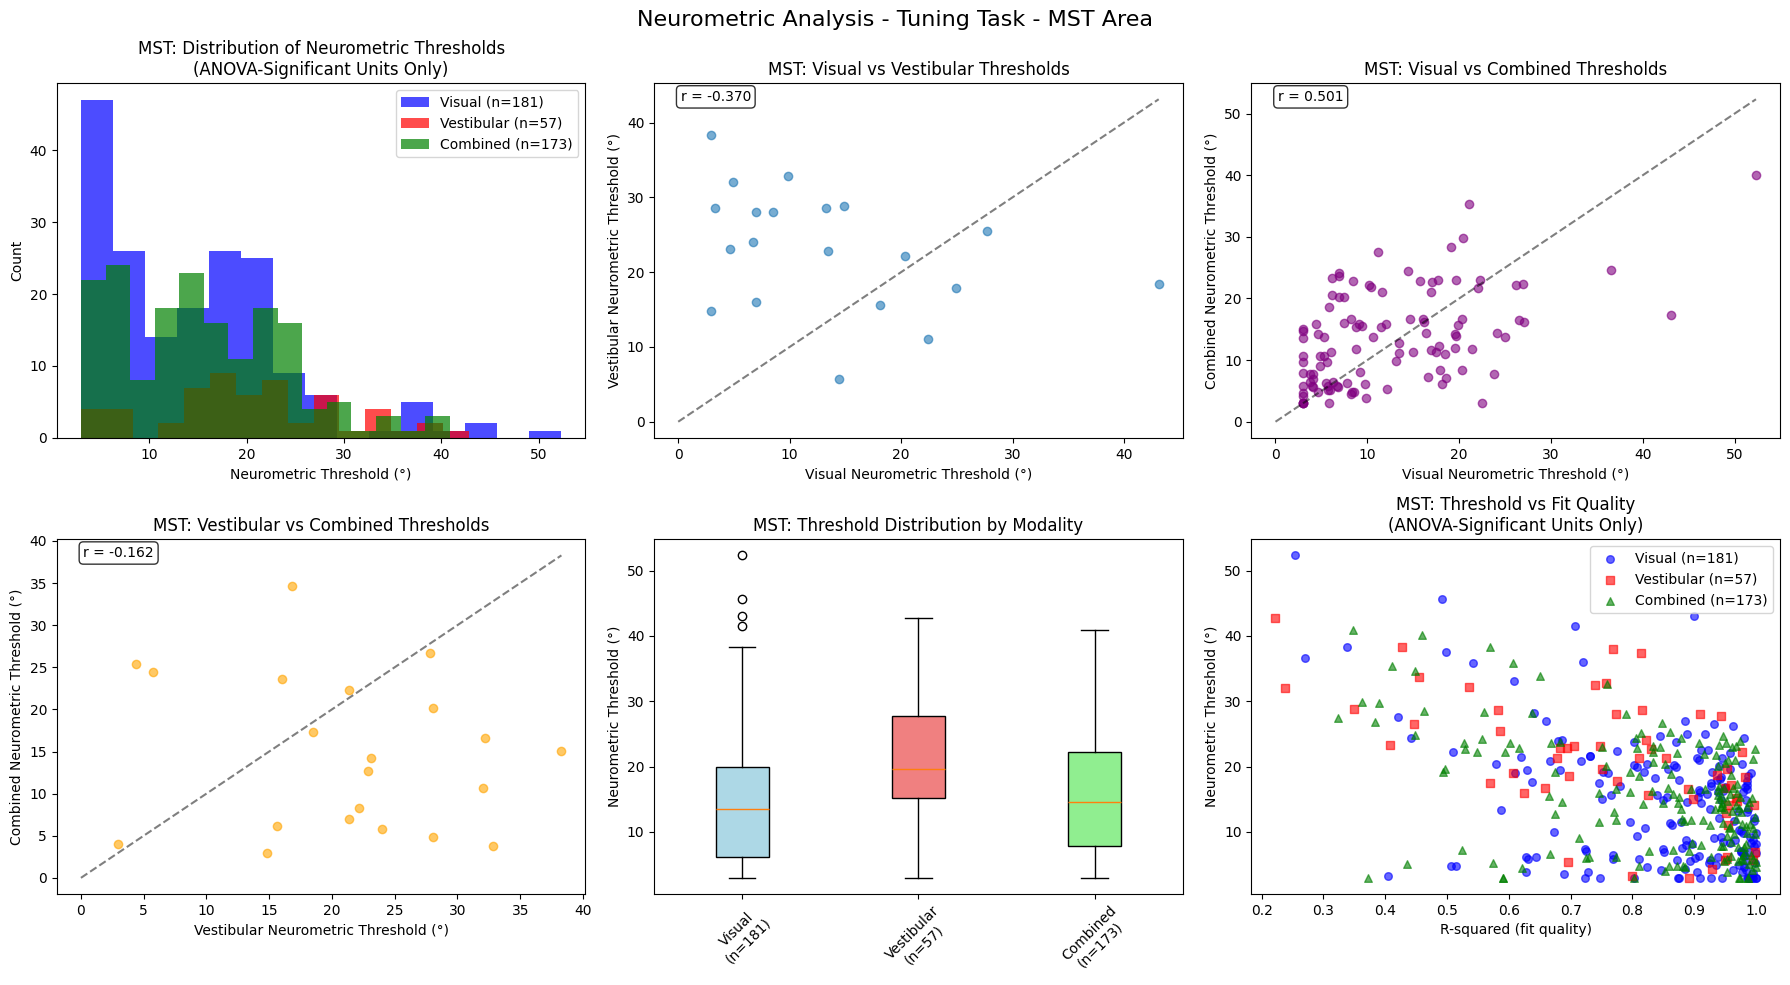


Summary Statistics for MST (Tuning Task - ANOVA-Significant Units Only):
Visual selective units with valid thresholds: 181 out of 181 visual-selective units
  Mean: 14.31°
  Median: 13.46°
  Range: 2.98° - 52.32°
  Mean R²: 0.845

Vestibular selective units with valid thresholds: 57 out of 57 vestibular-selective units
  Mean: 20.62°
  Median: 19.64°
  Range: 2.98° - 42.79°
  Mean R²: 0.766

Combined selective units with valid thresholds: 173 out of 173 combined-selective units
  Mean: 15.42°
  Median: 14.62°
  Range: 2.98° - 40.85°
  Mean R²: 0.829

----------------------------------------
AREA: VPS
----------------------------------------
Total units in VPS: 377
Visual selective: 199 units
Vestibular selective: 88 units
Combined selective: 193 units


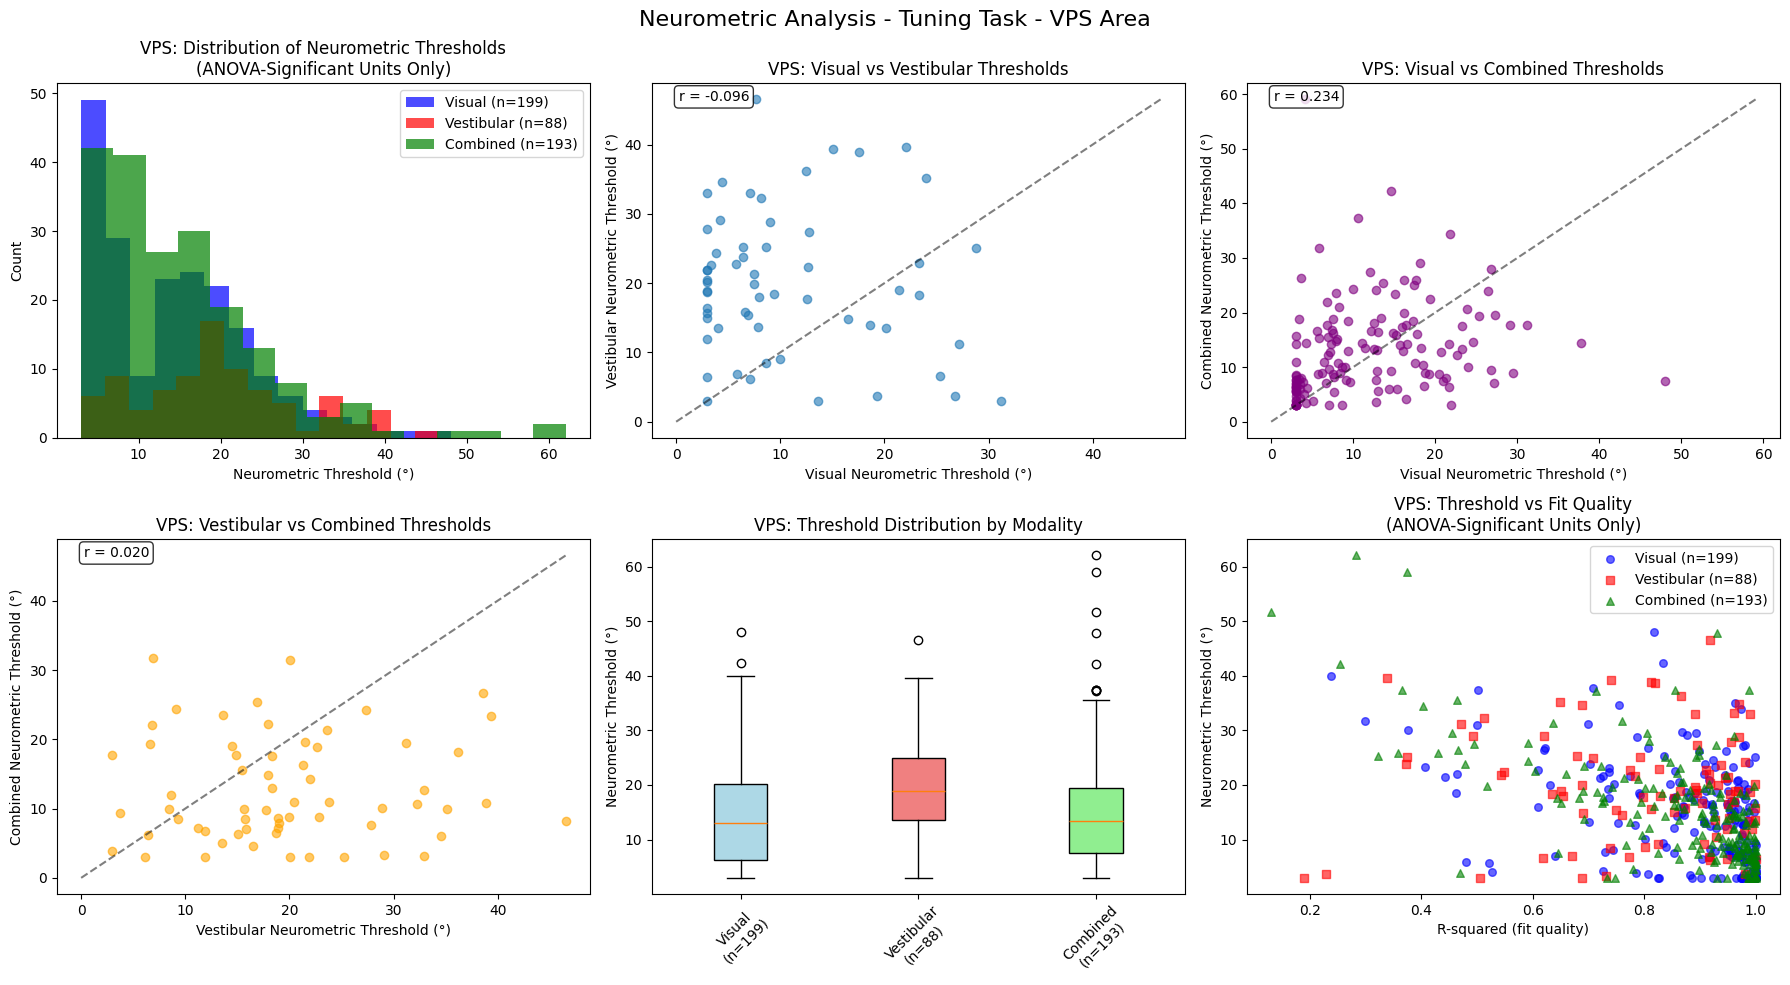


Summary Statistics for VPS (Tuning Task - ANOVA-Significant Units Only):
Visual selective units with valid thresholds: 199 out of 199 visual-selective units
  Mean: 14.12°
  Median: 13.07°
  Range: 2.98° - 48.04°
  Mean R²: 0.882

Vestibular selective units with valid thresholds: 88 out of 88 vestibular-selective units
  Mean: 19.53°
  Median: 18.92°
  Range: 2.98° - 46.54°
  Mean R²: 0.803

Combined selective units with valid thresholds: 193 out of 193 combined-selective units
  Mean: 15.02°
  Median: 13.44°
  Range: 2.98° - 62.07°
  Mean R²: 0.860

ANALYZING REGULAR DATA BY BRAIN AREA
File: D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMP_neuralfeatures\zarya_pooled_neural_features_regular_saccOnset.csv
Available columns: ['subject', 'date', 'alignment', 'is_tuning', 'unit_idx', 'area', 'absolute_x', 'absolute_y', 'relative_x', 'relative_y', 'absolute_depth', 'relative_depth', 'overall_firing_rate', 'ves_selective', 'ves_pval', 'vis_selective', 'vis_pval', 'comb_selective

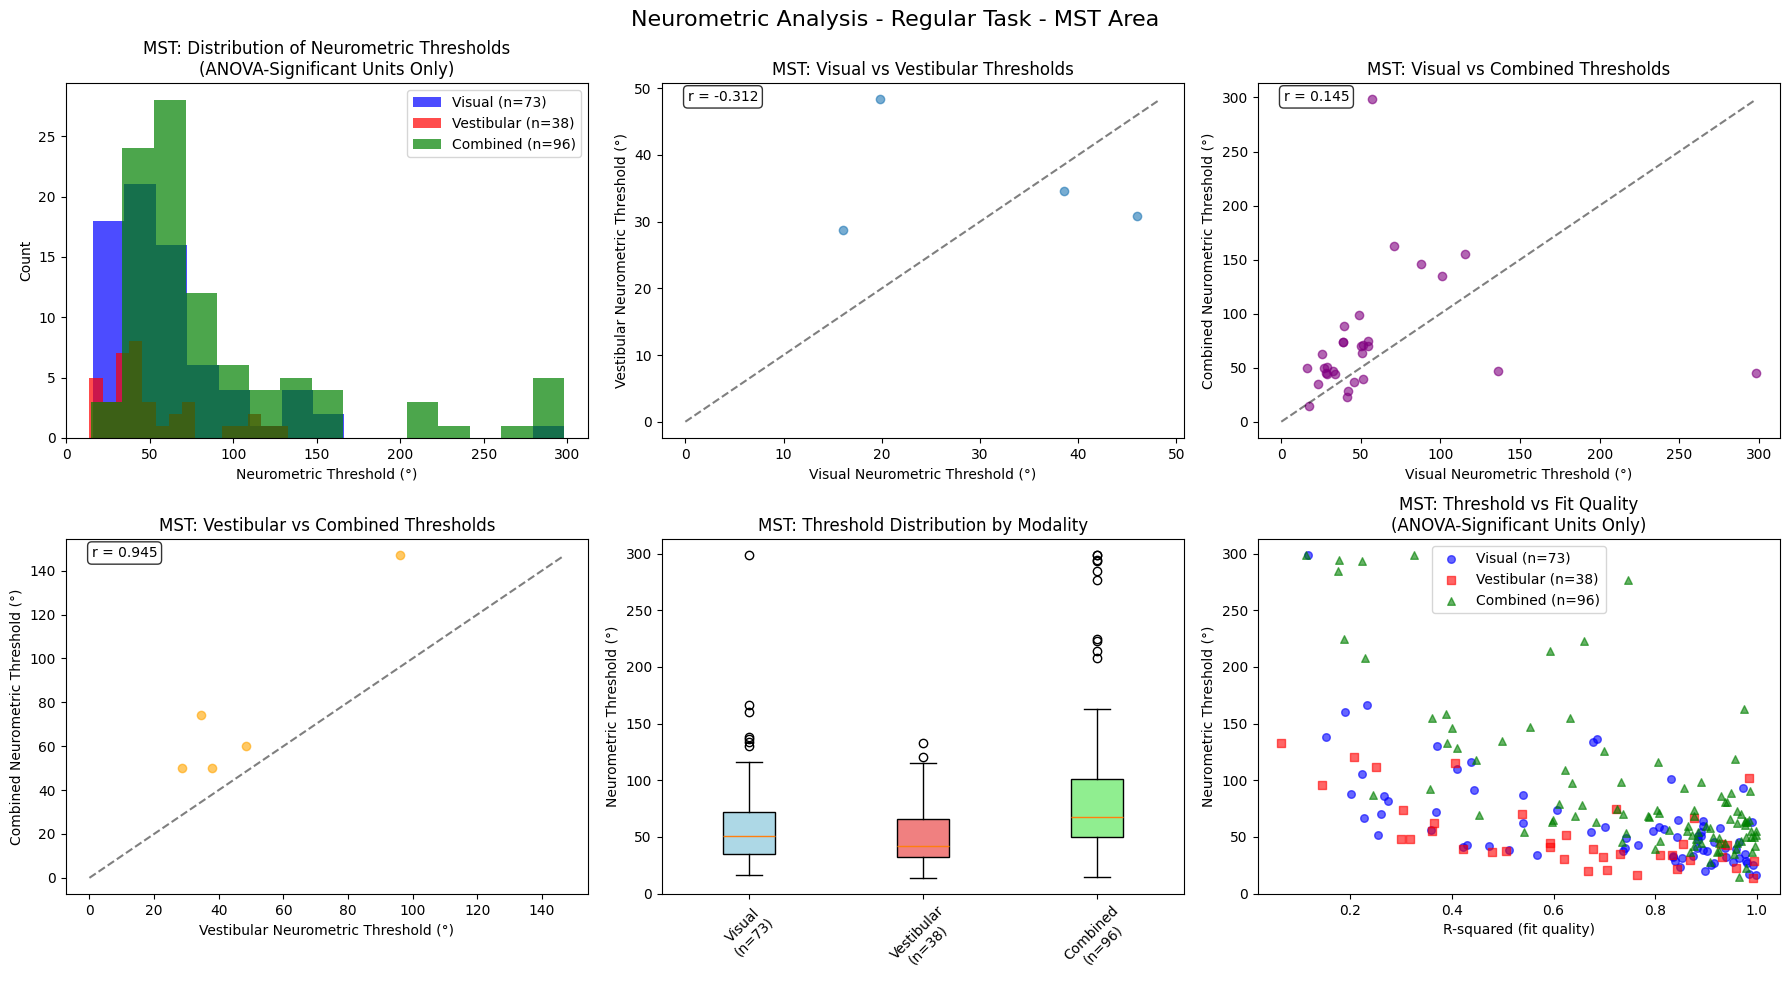


Summary Statistics for MST (Regular Task - ANOVA-Significant Units Only):
Visual selective units with valid thresholds: 73 out of 73 visual-selective units
  Mean: 62.68°
  Median: 50.85°
  Range: 16.08° - 298.34°
  Mean R²: 0.696

Vestibular selective units with valid thresholds: 38 out of 38 vestibular-selective units
  Mean: 51.88°
  Median: 41.86°
  Range: 13.89° - 132.72°
  Mean R²: 0.628

Combined selective units with valid thresholds: 96 out of 96 combined-selective units
  Mean: 92.13°
  Median: 67.99°
  Range: 14.72° - 298.34°
  Mean R²: 0.759

----------------------------------------
AREA: VPS
----------------------------------------
Total units in VPS: 377
Visual selective: 72 units
Vestibular selective: 26 units
Combined selective: 115 units


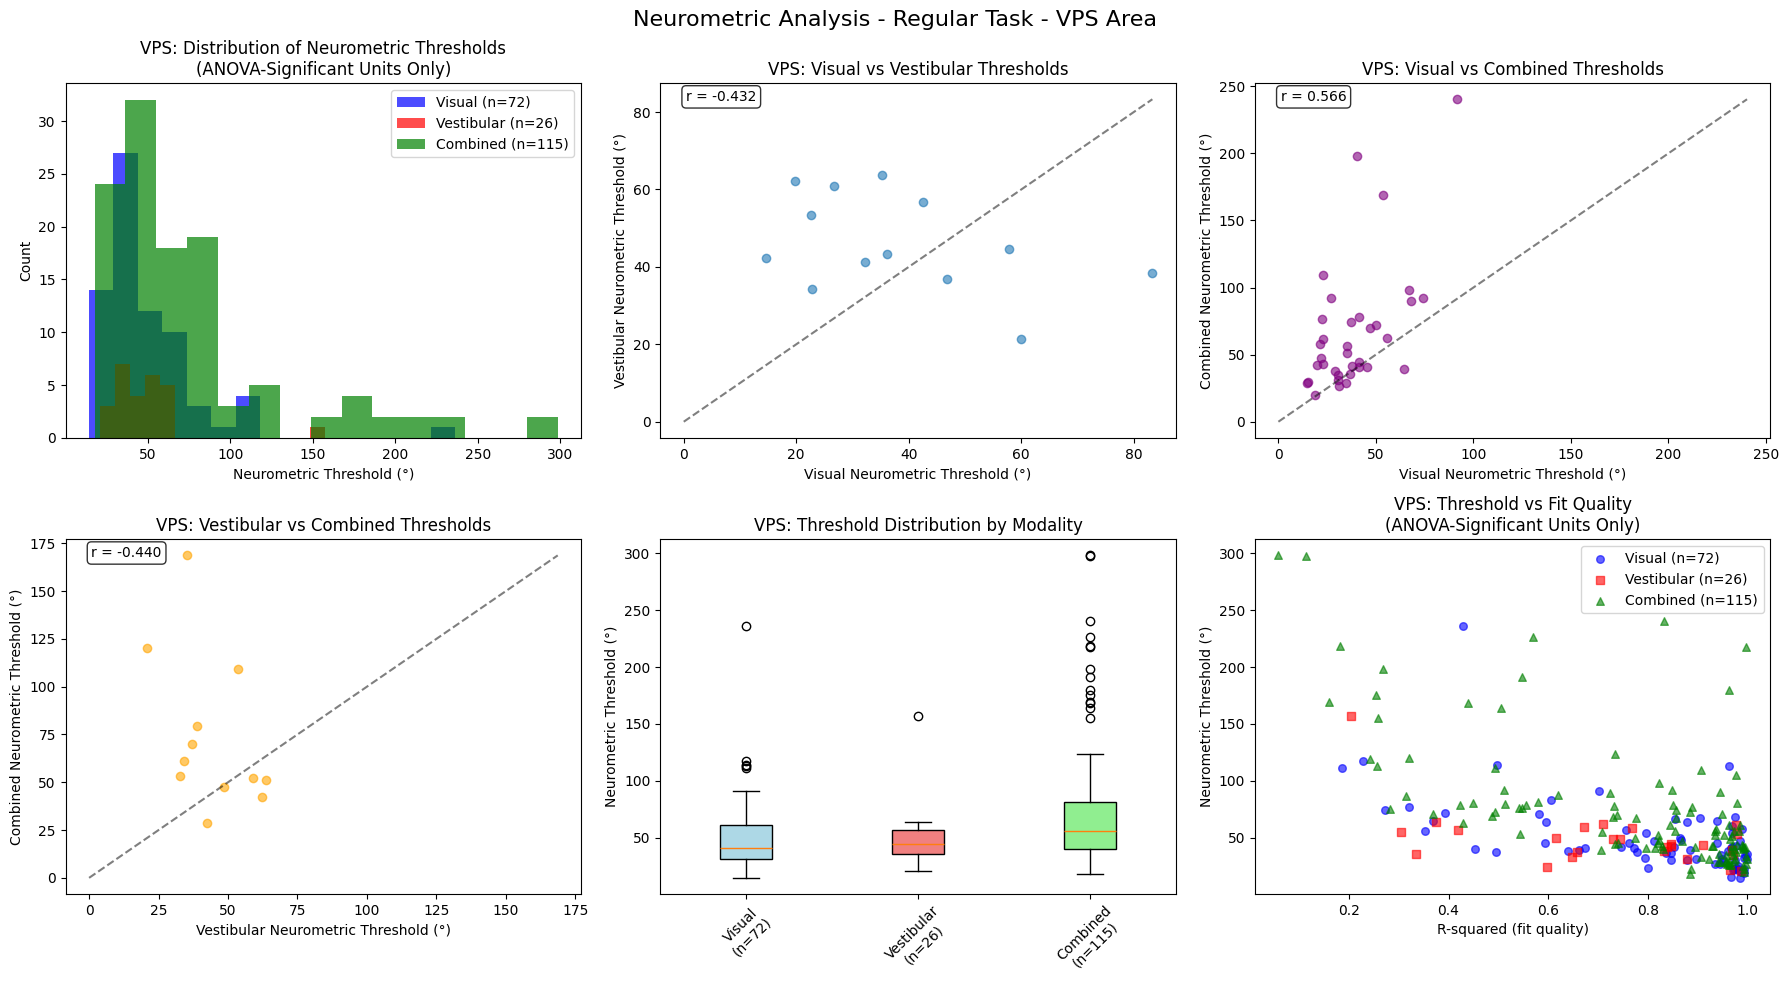


Summary Statistics for VPS (Regular Task - ANOVA-Significant Units Only):
Visual selective units with valid thresholds: 72 out of 72 visual-selective units
  Mean: 49.67°
  Median: 41.19°
  Range: 14.57° - 236.23°
  Mean R²: 0.800

Vestibular selective units with valid thresholds: 26 out of 26 vestibular-selective units
  Mean: 48.44°
  Median: 44.04°
  Range: 20.97° - 157.30°
  Mean R²: 0.722

Combined selective units with valid thresholds: 115 out of 115 combined-selective units
  Mean: 74.89°
  Median: 55.96°
  Range: 17.92° - 298.34°
  Mean R²: 0.769


In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def classify_multisensory_units_matching_sci(tuning_df):
    """
    Use the EXACT same classification logic as the SCI analysis
    This should give you the same 175 multisensory units
    """
    # Add multisensory type classification to dataframe
    tuning_df['multisensory_type'] = 'None'
    
    multisensory_mask = []
    threshold = 0.05  
    
    for idx, row in tuning_df.iterrows():
        # Apply the EXACT same selectivity definitions as SCI code
        vis_selective = row['vis_pval'] < threshold and row['ves_pval'] > threshold
        ves_selective = row['ves_pval'] < threshold and row['vis_pval'] > threshold
        comb_selective = (row['vis_pval'] < threshold and row['ves_pval'] < threshold) or row['comb_pval'] < threshold
        
        # Determine unit type based on selectivity patterns - EXACT same logic
        if vis_selective and not ves_selective and not comb_selective:
            tuning_df.loc[idx, 'multisensory_type'] = 'Visual_only'
            multisensory_mask.append(False)
        elif ves_selective and not vis_selective and not comb_selective:
            tuning_df.loc[idx, 'multisensory_type'] = 'Vestibular_only'
            multisensory_mask.append(False)
        elif comb_selective:
            tuning_df.loc[idx, 'multisensory_type'] = 'Multisensory'
            multisensory_mask.append(True)
         
            
    
    return np.array(multisensory_mask)
def analyze_neurometric_data_by_area(file_path, task_type="tuning"):
    """
    Analyze neurometric data for either tuning or regular task, separated by brain area
    
    Parameters:
    -----------
    file_path : str
        Path to the CSV file
    task_type : str
        "tuning" or "regular" to adjust analysis accordingly
    """
    
    # Load the data
    df = pd.read_csv(file_path)
    
    print(f"\n{'='*60}")
    print(f"ANALYZING {task_type.upper()} DATA BY BRAIN AREA")
    print(f"{'='*60}")
    print(f"File: {file_path}")
    
    # Check available columns
    print(f"Available columns: {list(df.columns)}")
    
    # Define expected column names and check which ones exist
    threshold_cols = {
        'vis': 'vis_neurometric_threshold',
        'ves': 'ves_neurometric_threshold', 
        'comb': 'comb_neurometric_threshold'
    }
    
    r2_cols = {
        'vis': 'vis_neurometric_r2',
        'ves': 'ves_neurometric_r2',
        'comb': 'comb_neurometric_r2'
    }
    
    selective_cols = {
        'vis': 'vis_selective',
        'ves': 'ves_selective',
        'comb': 'comb_selective'
    }
    
    # Check which columns actually exist
    available_threshold_cols = {k: v for k, v in threshold_cols.items() if v in df.columns}
    available_r2_cols = {k: v for k, v in r2_cols.items() if v in df.columns}
    available_selective_cols = {k: v for k, v in selective_cols.items() if v in df.columns}
    
    print(f"Available threshold columns: {list(available_threshold_cols.values())}")
    print(f"Available R² columns: {list(available_r2_cols.values())}")
    print(f"Available selective columns: {list(available_selective_cols.values())}")
    
    # Get unique areas
    areas = df['area'].unique()
    print(f"Brain areas found: {areas}")
    
    # Create separate analysis for each area
    for area in areas:
        print(f"\n{'-'*40}")
        print(f"AREA: {area}")
        print(f"{'-'*40}")
        
        # Filter data for this area
        area_df = df[df['area'] == area].copy()
        
        # Filter for ANOVA-significant units only (only for available modalities)
        vis_significant = area_df[area_df[available_selective_cols.get('vis', 'vis_selective')] == 1].copy() if 'vis' in available_selective_cols else pd.DataFrame()
        ves_significant = area_df[area_df[available_selective_cols.get('ves', 'ves_selective')] == 1].copy() if 'ves' in available_selective_cols else pd.DataFrame()
        comb_significant = area_df[area_df[available_selective_cols.get('comb', 'comb_selective')] == 1].copy() if 'comb' in available_selective_cols else pd.DataFrame()

        print(f"Total units in {area}: {len(area_df)}")
        print(f"Visual selective: {len(vis_significant)} units")
        print(f"Vestibular selective: {len(ves_significant)} units")
        print(f"Combined selective: {len(comb_significant)} units")

        if len(area_df) == 0:
            print(f"No units found in {area}, skipping...")
            continue

        # Create figure with subplots for this area
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        fig.suptitle(f'Neurometric Analysis - {task_type.title()} Task - {area} Area', fontsize=16, y=0.98)

        # 1. Distribution of thresholds (only ANOVA-significant units)
        if 'vis' in available_threshold_cols and len(vis_significant) > 0:
            vis_thresh_data = vis_significant[available_threshold_cols['vis']].dropna()
            if len(vis_thresh_data) > 0:
                axes[0,0].hist(vis_thresh_data, bins=15, alpha=0.7, 
                               label=f'Visual (n={len(vis_thresh_data)})', color='blue')
        
        if 'ves' in available_threshold_cols and len(ves_significant) > 0:
            ves_thresh_data = ves_significant[available_threshold_cols['ves']].dropna()
            if len(ves_thresh_data) > 0:
                axes[0,0].hist(ves_thresh_data, bins=15, alpha=0.7, 
                               label=f'Vestibular (n={len(ves_thresh_data)})', color='red')
        
        if 'comb' in available_threshold_cols and len(comb_significant) > 0:
            comb_thresh_data = comb_significant[available_threshold_cols['comb']].dropna()
            if len(comb_thresh_data) > 0:
                axes[0,0].hist(comb_thresh_data, bins=15, alpha=0.7, 
                               label=f'Combined (n={len(comb_thresh_data)})', color='green')
        
        axes[0,0].set_xlabel('Neurometric Threshold (°)')
        axes[0,0].set_ylabel('Count')
        axes[0,0].set_title(f'{area}: Distribution of Neurometric Thresholds\n(ANOVA-Significant Units Only)')
        axes[0,0].legend()

        # 2. Visual vs Vestibular thresholds (both must be significant)
        if 'vis' in available_threshold_cols and 'ves' in available_threshold_cols and 'vis' in available_selective_cols and 'ves' in available_selective_cols:
            vis_and_ves_sig = area_df[(area_df[available_selective_cols['vis']] == 1) & (area_df[available_selective_cols['ves']] == 1)]
            valid_both = vis_and_ves_sig.dropna(subset=[available_threshold_cols['vis'], available_threshold_cols['ves']])

            if len(valid_both) > 0:
                axes[0,1].scatter(valid_both[available_threshold_cols['vis']], valid_both[available_threshold_cols['ves']], alpha=0.6)
                max_val = max(valid_both[available_threshold_cols['vis']].max(), valid_both[available_threshold_cols['ves']].max())
                axes[0,1].plot([0, max_val], [0, max_val], 'k--', alpha=0.5)  # Unity line
                axes[0,1].set_xlabel('Visual Neurometric Threshold (°)')
                axes[0,1].set_ylabel('Vestibular Neurometric Threshold (°)')
                axes[0,1].set_title(f'{area}: Visual vs Vestibular Thresholds\n(Both Significant, n={len(valid_both)})')
                
                # Add correlation info
                if len(valid_both) > 2:
                    corr = np.corrcoef(valid_both[available_threshold_cols['vis']], valid_both[available_threshold_cols['ves']])[0,1]
                    axes[0,1].text(0.05, 0.95, f'r = {corr:.3f}', transform=axes[0,1].transAxes, 
                                  bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
            else:
                axes[0,1].text(0.5, 0.5, 'No units significant\nfor both modalities', 
                               ha='center', va='center', transform=axes[0,1].transAxes)
        else:
            axes[0,1].text(0.5, 0.5, 'Required columns\nnot available', 
                           ha='center', va='center', transform=axes[0,1].transAxes)
        
        axes[0,1].set_title(f'{area}: Visual vs Vestibular Thresholds')

        # 3. Combined vs Visual thresholds (both must be significant)
        if 'vis' in available_threshold_cols and 'comb' in available_threshold_cols and 'vis' in available_selective_cols and 'comb' in available_selective_cols:
            vis_and_comb_sig = area_df[(area_df[available_selective_cols['vis']] == 1) & (area_df[available_selective_cols['comb']] == 1)]
            valid_vis_comb = vis_and_comb_sig.dropna(subset=[available_threshold_cols['vis'], available_threshold_cols['comb']])

            if len(valid_vis_comb) > 0:
                axes[0,2].scatter(valid_vis_comb[available_threshold_cols['vis']], valid_vis_comb[available_threshold_cols['comb']], 
                                 alpha=0.6, color='purple')
                max_val = max(valid_vis_comb[available_threshold_cols['vis']].max(), valid_vis_comb[available_threshold_cols['comb']].max())
                axes[0,2].plot([0, max_val], [0, max_val], 'k--', alpha=0.5)  # Unity line
                axes[0,2].set_xlabel('Visual Neurometric Threshold (°)')
                axes[0,2].set_ylabel('Combined Neurometric Threshold (°)')
                axes[0,2].set_title(f'{area}: Visual vs Combined Thresholds\n(Both Significant, n={len(valid_vis_comb)})')
                
                # Add correlation info
                if len(valid_vis_comb) > 2:
                    corr = np.corrcoef(valid_vis_comb[available_threshold_cols['vis']], valid_vis_comb[available_threshold_cols['comb']])[0,1]
                    axes[0,2].text(0.05, 0.95, f'r = {corr:.3f}', transform=axes[0,2].transAxes,
                                  bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
            else:
                axes[0,2].text(0.5, 0.5, 'No units significant\nfor both modalities', 
                               ha='center', va='center', transform=axes[0,2].transAxes)
        else:
            axes[0,2].text(0.5, 0.5, 'Required columns\nnot available', 
                           ha='center', va='center', transform=axes[0,2].transAxes)
        
        axes[0,2].set_title(f'{area}: Visual vs Combined Thresholds')

        # 4. Combined vs Vestibular thresholds (both must be significant)
        if 'ves' in available_threshold_cols and 'comb' in available_threshold_cols and 'ves' in available_selective_cols and 'comb' in available_selective_cols:
            ves_and_comb_sig = area_df[(area_df[available_selective_cols['ves']] == 1) & (area_df[available_selective_cols['comb']] == 1)]
            valid_ves_comb = ves_and_comb_sig.dropna(subset=[available_threshold_cols['ves'], available_threshold_cols['comb']])

            if len(valid_ves_comb) > 0:
                axes[1,0].scatter(valid_ves_comb[available_threshold_cols['ves']], valid_ves_comb[available_threshold_cols['comb']], 
                                 alpha=0.6, color='orange')
                max_val = max(valid_ves_comb[available_threshold_cols['ves']].max(), valid_ves_comb[available_threshold_cols['comb']].max())
                axes[1,0].plot([0, max_val], [0, max_val], 'k--', alpha=0.5)  # Unity line
                axes[1,0].set_xlabel('Vestibular Neurometric Threshold (°)')
                axes[1,0].set_ylabel('Combined Neurometric Threshold (°)')
                axes[1,0].set_title(f'{area}: Vestibular vs Combined Thresholds\n(Both Significant, n={len(valid_ves_comb)})')
                
                # Add correlation info
                if len(valid_ves_comb) > 2:
                    corr = np.corrcoef(valid_ves_comb[available_threshold_cols['ves']], valid_ves_comb[available_threshold_cols['comb']])[0,1]
                    axes[1,0].text(0.05, 0.95, f'r = {corr:.3f}', transform=axes[1,0].transAxes,
                                  bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
            else:
                axes[1,0].text(0.5, 0.5, 'No units significant\nfor both modalities', 
                               ha='center', va='center', transform=axes[1,0].transAxes)
        else:
            axes[1,0].text(0.5, 0.5, 'Required columns\nnot available', 
                           ha='center', va='center', transform=axes[1,0].transAxes)
        
        axes[1,0].set_title(f'{area}: Vestibular vs Combined Thresholds')

        # 5. Box plot comparison of thresholds by modality for this area
        threshold_data = []
        threshold_labels = []
        
        if 'vis' in available_threshold_cols and len(vis_significant) > 0:
            vis_thresh_clean = vis_significant[available_threshold_cols['vis']].dropna()
            if len(vis_thresh_clean) > 0:
                threshold_data.append(vis_thresh_clean.values)
                threshold_labels.append(f'Visual\n(n={len(vis_thresh_clean)})')
        
        if 'ves' in available_threshold_cols and len(ves_significant) > 0:
            ves_thresh_clean = ves_significant[available_threshold_cols['ves']].dropna()
            if len(ves_thresh_clean) > 0:
                threshold_data.append(ves_thresh_clean.values)
                threshold_labels.append(f'Vestibular\n(n={len(ves_thresh_clean)})')
        
        if 'comb' in available_threshold_cols and len(comb_significant) > 0:
            comb_thresh_clean = comb_significant[available_threshold_cols['comb']].dropna()
            if len(comb_thresh_clean) > 0:
                threshold_data.append(comb_thresh_clean.values)
                threshold_labels.append(f'Combined\n(n={len(comb_thresh_clean)})')
        
        if len(threshold_data) > 0:
            bp = axes[1,1].boxplot(threshold_data, labels=threshold_labels, patch_artist=True)
            colors = ['lightblue', 'lightcoral', 'lightgreen']
            for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
                patch.set_facecolor(color)
            axes[1,1].set_ylabel('Neurometric Threshold (°)')
            axes[1,1].set_title(f'{area}: Threshold Distribution by Modality')
            axes[1,1].tick_params(axis='x', rotation=45)
        else:
            axes[1,1].text(0.5, 0.5, 'No valid thresholds\nfor any modality', 
                           ha='center', va='center', transform=axes[1,1].transAxes)
            axes[1,1].set_title(f'{area}: Threshold Distribution by Modality')

        # 6. R-squared values (fit quality) for significant units only
        legend_added = False
        
        if 'vis' in available_r2_cols and 'vis' in available_threshold_cols and len(vis_significant) > 0:
            vis_r2_data = vis_significant[available_r2_cols['vis']].dropna()
            vis_thresh_data = vis_significant[available_threshold_cols['vis']].dropna()
            if len(vis_r2_data) > 0 and len(vis_thresh_data) > 0:
                # Match indices
                common_idx = vis_r2_data.index.intersection(vis_thresh_data.index)
                if len(common_idx) > 0:
                    axes[1,2].scatter(vis_r2_data[common_idx], vis_thresh_data[common_idx], 
                                     alpha=0.6, label=f'Visual (n={len(common_idx)})', 
                                     color='blue', marker='o', s=30)
                    legend_added = True
        
        if 'ves' in available_r2_cols and 'ves' in available_threshold_cols and len(ves_significant) > 0:
            ves_r2_data = ves_significant[available_r2_cols['ves']].dropna()
            ves_thresh_data = ves_significant[available_threshold_cols['ves']].dropna()
            if len(ves_r2_data) > 0 and len(ves_thresh_data) > 0:
                # Match indices
                common_idx = ves_r2_data.index.intersection(ves_thresh_data.index)
                if len(common_idx) > 0:
                    axes[1,2].scatter(ves_r2_data[common_idx], ves_thresh_data[common_idx], 
                                     alpha=0.6, label=f'Vestibular (n={len(common_idx)})', 
                                     color='red', marker='s', s=30)
                    legend_added = True
        
        if 'comb' in available_r2_cols and 'comb' in available_threshold_cols and len(comb_significant) > 0:
            comb_r2_data = comb_significant[available_r2_cols['comb']].dropna()
            comb_thresh_data = comb_significant[available_threshold_cols['comb']].dropna()
            if len(comb_r2_data) > 0 and len(comb_thresh_data) > 0:
                # Match indices
                common_idx = comb_r2_data.index.intersection(comb_thresh_data.index)
                if len(common_idx) > 0:
                    axes[1,2].scatter(comb_r2_data[common_idx], comb_thresh_data[common_idx], 
                                     alpha=0.6, label=f'Combined (n={len(common_idx)})', 
                                     color='green', marker='^', s=30)
                    legend_added = True
        
        axes[1,2].set_xlabel('R-squared (fit quality)')
        axes[1,2].set_ylabel('Neurometric Threshold (°)')
        axes[1,2].set_title(f'{area}: Threshold vs Fit Quality\n(ANOVA-Significant Units Only)')
        
        if legend_added:
            axes[1,2].legend()
        else:
            axes[1,2].text(0.5, 0.5, 'No R² data available', 
                           ha='center', va='center', transform=axes[1,2].transAxes)

        plt.tight_layout()
        plt.show()

        # Print summary statistics for this area (only for available columns)
        print(f"\nSummary Statistics for {area} ({task_type.title()} Task - ANOVA-Significant Units Only):")

        if 'vis' in available_threshold_cols and len(vis_significant) > 0:
            vis_thresh_count = vis_significant[available_threshold_cols['vis']].count()
            print(f"Visual selective units with valid thresholds: {vis_thresh_count} out of {len(vis_significant)} visual-selective units")
            if vis_thresh_count > 0:
                vis_thresh_data = vis_significant[available_threshold_cols['vis']].dropna()
                print(f"  Mean: {vis_thresh_data.mean():.2f}°")
                print(f"  Median: {vis_thresh_data.median():.2f}°")
                print(f"  Range: {vis_thresh_data.min():.2f}° - {vis_thresh_data.max():.2f}°")
                if 'vis' in available_r2_cols:
                    vis_r2_data = vis_significant[available_r2_cols['vis']].dropna()
                    if len(vis_r2_data) > 0:
                        print(f"  Mean R²: {vis_r2_data.mean():.3f}")

        if 'ves' in available_threshold_cols and len(ves_significant) > 0:
            ves_thresh_count = ves_significant[available_threshold_cols['ves']].count()
            print(f"\nVestibular selective units with valid thresholds: {ves_thresh_count} out of {len(ves_significant)} vestibular-selective units")
            if ves_thresh_count > 0:
                ves_thresh_data = ves_significant[available_threshold_cols['ves']].dropna()
                print(f"  Mean: {ves_thresh_data.mean():.2f}°")
                print(f"  Median: {ves_thresh_data.median():.2f}°")
                print(f"  Range: {ves_thresh_data.min():.2f}° - {ves_thresh_data.max():.2f}°")
                if 'ves' in available_r2_cols:
                    ves_r2_data = ves_significant[available_r2_cols['ves']].dropna()
                    if len(ves_r2_data) > 0:
                        print(f"  Mean R²: {ves_r2_data.mean():.3f}")

        if 'comb' in available_threshold_cols and len(comb_significant) > 0:
            comb_thresh_count = comb_significant[available_threshold_cols['comb']].count()
            print(f"\nCombined selective units with valid thresholds: {comb_thresh_count} out of {len(comb_significant)} combined-selective units")
            if comb_thresh_count > 0:
                comb_thresh_data = comb_significant[available_threshold_cols['comb']].dropna()
                print(f"  Mean: {comb_thresh_data.mean():.2f}°")
                print(f"  Median: {comb_thresh_data.median():.2f}°")
                print(f"  Range: {comb_thresh_data.min():.2f}° - {comb_thresh_data.max():.2f}°")
                if 'comb' in available_r2_cols:
                    comb_r2_data = comb_significant[available_r2_cols['comb']].dropna()
                    if len(comb_r2_data) > 0:
                        print(f"  Mean R²: {comb_r2_data.mean():.3f}")
    
    return df

# Usage:
# Analyze tuning data by area
tuning_file = r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMPtuning_neuralfeatures\zarya_pooled_neural_features_tuning_stimOn.csv'
tuning_df = analyze_neurometric_data_by_area(tuning_file, "tuning")

# Analyze regular task data by area
regular_file = r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMP_neuralfeatures\zarya_pooled_neural_features_regular_saccOnset.csv'
regular_df = analyze_neurometric_data_by_area(regular_file, "regular")

### Neurometric tuning vs dots3DMP

Total units in tuning dataset: 972
Multisensory units from tuning task: 383

Creating neurothreshold plot for Lower Activated Area...
Total units in Lower Activated Area: 595
Multisensory units from tuning task: 179
Multisensory unit types (from tuning task):
  Mixed_multisensory: 103 (57.5%)
  Integrative: 56 (31.3%)
  Additive: 20 (11.2%)
Units available for comparison:
  Tuning RT task: 179 multisensory units
  Regular task: 179 corresponding units
Visual: 104/179 units pass R²≥0.5
Visual modality: 104 paired thresholds
Vestibular: 68/178 units pass R²≥0.5
Vestibular modality: 68 paired thresholds
Combined: 99/179 units pass R²≥0.5
Combined modality: 99 paired thresholds

Statistical comparisons for Lower Activated Area:
  Visual: Tuning RT=23.61° vs Regular=59.80° (+153.3%), p=0.0000***
  Vestibular: Tuning RT=43.45° vs Regular=55.41° (+27.5%), p=0.0005***
  Combined: Tuning RT=27.87° vs Regular=91.07° (+226.7%), p=0.0000***


C:\Users\fetschlab\AppData\Local\Temp\ipykernel_14404\3794331534.py:474: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


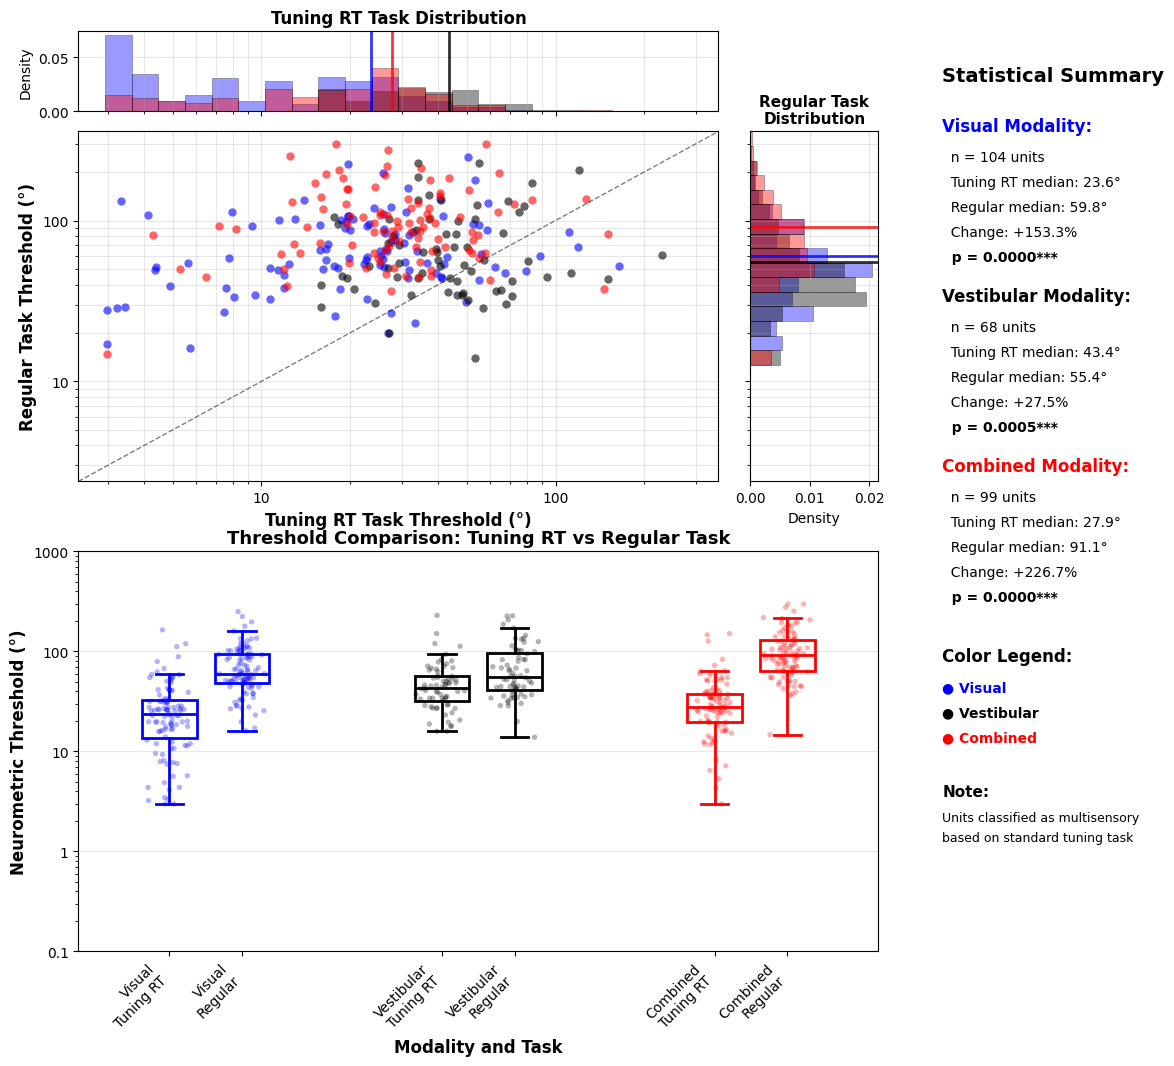


Summary for Lower Activated Area (Multisensory from Tuning Task):
Visual: 104 units
  Tuning RT median: 23.61°, Regular median: 59.80°
Vestibular: 68 units
  Tuning RT median: 43.45°, Regular median: 55.41°
Combined: 99 units
  Tuning RT median: 27.87°, Regular median: 91.07°

Creating neurothreshold plot for Upper Activated Area...
Total units in Upper Activated Area: 377
Multisensory units from tuning task: 204
Multisensory unit types (from tuning task):
  Mixed_multisensory: 112 (54.9%)
  Additive: 59 (28.9%)
  Integrative: 33 (16.2%)
Units available for comparison:
  Tuning RT task: 204 multisensory units
  Regular task: 204 corresponding units
Visual: 118/204 units pass R²≥0.5
Visual modality: 118 paired thresholds
Vestibular: 78/203 units pass R²≥0.5
Vestibular modality: 78 paired thresholds
Combined: 115/202 units pass R²≥0.5
Combined modality: 115 paired thresholds

Statistical comparisons for Upper Activated Area:
  Visual: Tuning RT=19.81° vs Regular=58.64° (+196.0%), p=0.00

C:\Users\fetschlab\AppData\Local\Temp\ipykernel_14404\3794331534.py:474: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


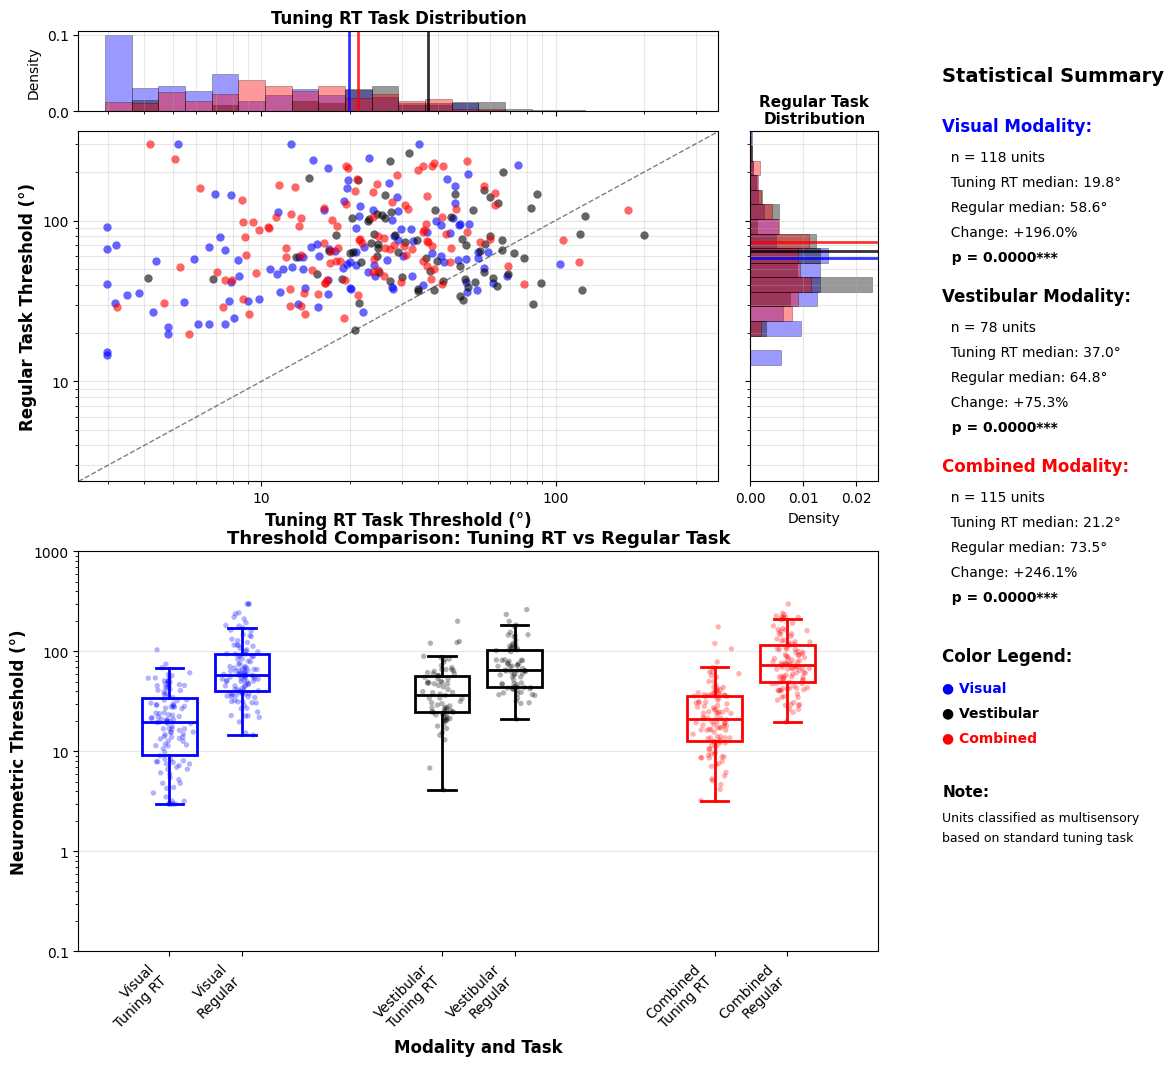


Summary for Upper Activated Area (Multisensory from Tuning Task):
Visual: 118 units
  Tuning RT median: 19.81°, Regular median: 58.64°
Vestibular: 78 units
  Tuning RT median: 36.97°, Regular median: 64.80°
Combined: 115 units
  Tuning RT median: 21.24°, Regular median: 73.50°


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wilcoxon, ttest_rel

def classify_multisensory_units_matching_sci(tuning_df):
    """
    Use the EXACT same classification logic as the SCI analysis
    """
    # Add multisensory type classification to dataframe
    tuning_df['multisensory_type'] = 'None'
    
    multisensory_mask = []
    threshold = 0.05  # SAME threshold as SCI analysis
    
    for idx, row in tuning_df.iterrows():
        # Apply the EXACT same selectivity definitions as SCI code
        vis_selective = row['vis_pval'] < threshold and row['ves_pval'] > threshold
        ves_selective = row['ves_pval'] < threshold and row['vis_pval'] > threshold
        comb_selective = (row['vis_pval'] < threshold and row['ves_pval'] < threshold) or row['comb_pval'] < threshold
        
        # Determine unit type based on selectivity patterns - EXACT same logic
        if vis_selective and not ves_selective and not comb_selective:
            tuning_df.loc[idx, 'multisensory_type'] = 'Visual_only'
            multisensory_mask.append(False)
        elif ves_selective and not vis_selective and not comb_selective:
            tuning_df.loc[idx, 'multisensory_type'] = 'Vestibular_only'
            multisensory_mask.append(False)
        elif comb_selective:
            # Further classify multisensory units - EXACT same logic
            additive_multisensory = row['vis_pval'] < threshold and row['ves_pval'] < threshold
            integrative_multisensory = (row['comb_pval'] < threshold and 
                                       row['vis_pval'] > threshold and 
                                       row['ves_pval'] > threshold)
            
            if additive_multisensory:
                tuning_df.loc[idx, 'multisensory_type'] = 'Additive'
                multisensory_mask.append(True)
            elif integrative_multisensory:
                tuning_df.loc[idx, 'multisensory_type'] = 'Integrative'
                multisensory_mask.append(True)
            else:
                tuning_df.loc[idx, 'multisensory_type'] = 'Mixed_multisensory'
                multisensory_mask.append(True)
        else:
            tuning_df.loc[idx, 'multisensory_type'] = 'Non_responsive'
            multisensory_mask.append(False)
    
    return np.array(multisensory_mask)

def get_significance_marker(p_val):
    """Get significance marker for p-value"""
    if p_val < 0.001:
        return "***"
    elif p_val < 0.01:
        return "**"
    elif p_val < 0.05:
        return "*"
    elif p_val < 0.1:
        return "†"
    else:
        return ""

def plot_neurothreshold_multisensory_units(tuning_file, tuning_rt_file, regular_file, r2_threshold=0.5):
    """
    Filter multisensory units based on TUNING task only, then compare tuning_RT vs regular thresholds
    """
    
    # Load all three datasets
    tuning_df = pd.read_csv(tuning_file)
    tuning_rt_df = pd.read_csv(tuning_rt_file)
    regular_df = pd.read_csv(regular_file)
    
    # Create unit keys for matching
    tuning_df['unit_key'] = tuning_df['subject'].astype(str) + '_' + tuning_df['date'].astype(str) + '_' + tuning_df['unit_idx'].astype(str)
    tuning_rt_df['unit_key'] = tuning_rt_df['subject'].astype(str) + '_' + tuning_rt_df['date'].astype(str) + '_' + tuning_rt_df['unit_idx'].astype(str)
    regular_df['unit_key'] = regular_df['subject'].astype(str) + '_' + regular_df['date'].astype(str) + '_' + regular_df['unit_idx'].astype(str)
    
    # Apply classification ONLY to tuning dataset (where SCI analysis was done)
    multisensory_mask_tuning = classify_multisensory_units_matching_sci(tuning_df)
    
    # Get multisensory units from tuning task
    multisensory_units_tuning = set(tuning_df[multisensory_mask_tuning]['unit_key'])
    
    print(f"Total units in tuning dataset: {len(tuning_df)}")
    print(f"Multisensory units from tuning task: {len(multisensory_units_tuning)}")
    
    # Define modalities and colors - Updated colors and same marker
    modalities = [
        ('vis', 'vis_neurometric_threshold', 'blue', 'Visual', 'o'),
        ('ves', 'ves_neurometric_threshold', 'black', 'Vestibular', 'o'), 
        ('comb', 'comb_neurometric_threshold', 'red', 'Combined', 'o')
    ]
    
    # Area name mapping (to avoid bias)
    area_display_names = {
        'MST': 'Lower Activated Area',
        'VPS': 'Upper Activated Area'
    }
    
    # Get unique areas and create separate plots
    areas = tuning_df['area'].unique()
    
    for area in areas:
        # Use display name
        display_name = area_display_names.get(area, area)
        print(f"\nCreating neurothreshold plot for {display_name}...")
        
        # Filter for this area
        tuning_area = tuning_df[tuning_df['area'] == area].copy()
        tuning_rt_area = tuning_rt_df[tuning_rt_df['area'] == area].copy()
        regular_area = regular_df[regular_df['area'] == area].copy()
        
        # Get multisensory units in this area (from tuning task)
        area_multisensory_units = multisensory_units_tuning.intersection(set(tuning_area['unit_key']))
        
        print(f"Total units in {display_name}: {len(tuning_area)}")
        print(f"Multisensory units from tuning task: {len(area_multisensory_units)}")
        
        # Print unit type breakdown for multisensory units
        tuning_multisensory_area = tuning_area[tuning_area['unit_key'].isin(area_multisensory_units)]
        if 'multisensory_type' in tuning_multisensory_area.columns:
            ms_counts = tuning_multisensory_area['multisensory_type'].value_counts()
            print("Multisensory unit types (from tuning task):")
            for ms_type, count in ms_counts.items():
                print(f"  {ms_type}: {count} ({count/len(tuning_multisensory_area)*100:.1f}%)")
        
        if len(area_multisensory_units) == 0:
            print(f"No multisensory units found in {display_name}, skipping...")
            continue
        
        # Filter datasets: multisensory units from tuning, corresponding units from tuning_RT and regular
        tuning_rt_multimodal = tuning_rt_area[tuning_rt_area['unit_key'].isin(area_multisensory_units)].copy()
        regular_multimodal = regular_area[regular_area['unit_key'].isin(area_multisensory_units)].copy()
        
        print(f"Units available for comparison:")
        print(f"  Tuning RT task: {len(tuning_rt_multimodal)} multisensory units")
        print(f"  Regular task: {len(regular_multimodal)} corresponding units")
        
        # Collect data for each modality
        all_tuning_rt_data = []
        all_regular_data = []
        all_colors = []
        all_labels = []
        all_markers = []
        
        # Store modality-specific data for median calculations and statistics
        modality_tuning_rt_data = {}
        modality_regular_data = {}
        modality_paired_data = {}  # For statistics
        
        for mod_key, thresh_col, color, label, marker in modalities:
            # Add R² columns
            r2_col_tuning_rt = thresh_col.replace('_threshold', '_r2')
            r2_col_regular = r2_col_tuning_rt
            
            if (thresh_col in tuning_rt_multimodal.columns and 
                thresh_col in regular_multimodal.columns and
                r2_col_tuning_rt in tuning_rt_multimodal.columns and
                r2_col_regular in regular_multimodal.columns):
                
                # Merge to get paired data
                merged = pd.merge(
                    tuning_rt_multimodal[['unit_key', thresh_col, r2_col_tuning_rt]].dropna(),
                    regular_multimodal[['unit_key', thresh_col, r2_col_regular]].dropna(),
                    on='unit_key', suffixes=('_tuning_rt', '_regular')
                )
                
                if len(merged) > 0:
                    tuning_rt_thresh = merged[f'{thresh_col}_tuning_rt'].values
                    regular_thresh = merged[f'{thresh_col}_regular'].values
                    tuning_rt_r2 = merged[f'{r2_col_tuning_rt}_tuning_rt'].values
                    regular_r2 = merged[f'{r2_col_regular}_regular'].values
                    
                    # Filter by R² threshold AND reasonable threshold values
                    valid_mask = (tuning_rt_thresh > 0.1) & (regular_thresh > 0.1) & \
                                (tuning_rt_thresh < 1000) & (regular_thresh < 1000) & \
                                (tuning_rt_r2 >= r2_threshold) & (regular_r2 >= r2_threshold)
                    
                    print(f"{label}: {np.sum(valid_mask)}/{len(merged)} units pass R²≥{r2_threshold}")
                    
                    if np.any(valid_mask):
                        tuning_rt_valid = tuning_rt_thresh[valid_mask]
                        regular_valid = regular_thresh[valid_mask]
                        
                        # Store modality-specific data
                        modality_tuning_rt_data[label] = tuning_rt_valid
                        modality_regular_data[label] = regular_valid
                        modality_paired_data[label] = (tuning_rt_valid, regular_valid)
                        
                        all_tuning_rt_data.extend(tuning_rt_valid)
                        all_regular_data.extend(regular_valid)
                        all_colors.extend([color] * np.sum(valid_mask))
                        all_labels.extend([label] * np.sum(valid_mask))
                        all_markers.extend([marker] * np.sum(valid_mask))
                        
                        print(f"{label} modality: {len(tuning_rt_valid)} paired thresholds")
        
        if len(all_tuning_rt_data) == 0:
            print(f"No valid threshold data found for multisensory units in {display_name}, skipping...")
            continue
        
        # Convert to numpy arrays
        all_tuning_rt_data = np.array(all_tuning_rt_data)
        all_regular_data = np.array(all_regular_data)
        
        # Create figure with adjusted size and layout
        fig = plt.figure(figsize=(16, 10))
        
        # Define the layout with space for text on the right
        main_ax = plt.axes([0.08, 0.55, 0.40, 0.35])    # Main scatter plot
        top_ax = plt.axes([0.08, 0.92, 0.40, 0.08])     # Top histogram
        right_ax = plt.axes([0.50, 0.55, 0.08, 0.35])   # Right histogram
        box_ax = plt.axes([0.08, 0.08, 0.50, 0.40])     # Boxplot
        
        # MAIN SCATTER PLOT (Log-Log)
        for mod_key, thresh_col, color, label, marker in modalities:
            if label in modality_tuning_rt_data:
                mod_tuning_rt = modality_tuning_rt_data[label]
                mod_regular = modality_regular_data[label]
                
                main_ax.loglog(mod_tuning_rt, mod_regular, marker, 
                              color=color, alpha=0.6, markersize=6,
                              markeredgecolor='none')
        
        # Set custom log ticks
        log_ticks = [0.1, 1, 10, 100, 1000]
        main_ax.set_xticks(log_ticks)
        main_ax.set_yticks(log_ticks)
        main_ax.set_xticklabels(['0.1', '1', '10', '100', '1000'])
        main_ax.set_yticklabels(['0.1', '1', '10', '100', '1000'])
        
        # Set axis limits
        min_thresh = min(np.min(all_tuning_rt_data), np.min(all_regular_data)) * 0.8
        max_thresh = max(np.max(all_tuning_rt_data), np.max(all_regular_data)) * 1.2
        main_ax.set_xlim(min_thresh, max_thresh)
        main_ax.set_ylim(min_thresh, max_thresh)
        
        # Add unity line
        main_ax.plot([min_thresh, max_thresh], [min_thresh, max_thresh], 'k--', alpha=0.5, linewidth=1)
        
        # Labels and formatting
        main_ax.set_xlabel('Tuning RT Task Threshold (°)', fontsize=12, fontweight='bold')
        main_ax.set_ylabel('Regular Task Threshold (°)', fontsize=12, fontweight='bold')
        main_ax.grid(True, alpha=0.3, which='both')
        
        # TOP HISTOGRAM (Tuning RT Task Thresholds)
        log_bins = np.logspace(np.log10(min_thresh), np.log10(max_thresh), 25)
        
        for mod_key, thresh_col, color, label, marker in modalities:
            if label in modality_tuning_rt_data:
                mod_tuning_rt = modality_tuning_rt_data[label]
                top_ax.hist(mod_tuning_rt, bins=log_bins, alpha=0.4, color=color, 
                           edgecolor='black', linewidth=0.5, density=True)
        
        top_ax.set_xscale('log')
        top_ax.set_xticks(log_ticks)
        top_ax.set_xticklabels(['0.1', '1', '10', '100', '1000'])
        
        # Add median lines
        for i, (mod_key, thresh_col, color, label, marker) in enumerate(modalities):
            if label in modality_tuning_rt_data:
                tuning_rt_median = np.median(modality_tuning_rt_data[label])
                top_ax.axvline(tuning_rt_median, color=color, linestyle='-', linewidth=2, alpha=0.8)
        
        top_ax.set_xlim(main_ax.get_xlim())
        top_ax.set_ylabel('Density', fontsize=10)
        top_ax.set_title('Tuning RT Task Distribution', fontsize=12, fontweight='bold')
        top_ax.tick_params(labelbottom=False)
        top_ax.grid(True, alpha=0.3, which='both')
        
        # RIGHT HISTOGRAM (Regular Task Thresholds)
       # RIGHT HISTOGRAM (Regular Task Thresholds)
        for mod_key, thresh_col, color, label, marker in modalities:
            if label in modality_regular_data:
                mod_regular = modality_regular_data[label]
                right_ax.hist(mod_regular, bins=log_bins, alpha=0.4, color=color,
                             edgecolor='black', linewidth=0.5, density=True, 
                             orientation='horizontal')
        
        right_ax.set_yscale('log')
        right_ax.set_yticks(log_ticks)
        right_ax.set_yticklabels(['0.1', '1', '10', '100', '1000'])
        
        # Add median lines
        for i, (mod_key, thresh_col, color, label, marker) in enumerate(modalities):
            if label in modality_regular_data:
                regular_median = np.median(modality_regular_data[label])
                right_ax.axhline(regular_median, color=color, linestyle='-', linewidth=2, alpha=0.8)
        
        right_ax.set_ylim(main_ax.get_ylim())
        right_ax.set_xlabel('Density', fontsize=10)
        right_ax.set_title('Regular Task\nDistribution', fontsize=11, fontweight='bold')
        right_ax.tick_params(labelleft=False)
        right_ax.grid(True, alpha=0.3, which='both')
        
        # BOXPLOT with individual data points and statistics
        print(f"\nStatistical comparisons for {display_name}:")
        
        # Collect statistics for text display
        stats_info = []
        
        # Create boxplot
        if len(modality_paired_data) > 0:
            # Prepare data for boxplot
            plot_data = []
            plot_labels = []
            plot_positions = []
            
            pos = 1
            for mod_key, thresh_col, color, label, marker in modalities:
                if label in modality_paired_data:
                    tuning_rt_vals, regular_vals = modality_paired_data[label]
                    
                    # Add tuning RT data
                    plot_data.append(tuning_rt_vals)
                    plot_labels.append(f'{label}\nTuning RT')
                    plot_positions.append(pos)
                    
                    # Add regular data
                    plot_data.append(regular_vals)
                    plot_labels.append(f'{label}\nRegular')
                    plot_positions.append(pos + 0.4)
                    
                    # Statistical test and collect info
                    if len(tuning_rt_vals) > 5:  # Need enough data for meaningful test
                        # Use Wilcoxon signed-rank test for paired data
                        stat, p_val = wilcoxon(tuning_rt_vals, regular_vals)
                        sig_marker = get_significance_marker(p_val)
                        
                        tuning_rt_median = np.median(tuning_rt_vals)
                        regular_median = np.median(regular_vals)
                        change_percent = ((regular_median - tuning_rt_median) / tuning_rt_median) * 100
                        
                        # Store info for text display
                        stats_info.append({
                            'label': label,
                            'color': color,
                            'n': len(tuning_rt_vals),
                            'tuning_rt_median': tuning_rt_median,
                            'regular_median': regular_median,
                            'change_percent': change_percent,
                            'p_val': p_val,
                            'sig_marker': sig_marker
                        })
                        
                        print(f"  {label}: Tuning RT={tuning_rt_median:.2f}° vs Regular={regular_median:.2f}° "
                              f"({change_percent:+.1f}%), p={p_val:.4f}{sig_marker}")
                    
                    pos += 1.5
            
            # Create boxplots with patch_artist=True to get Patch objects
            bp = box_ax.boxplot(plot_data, positions=plot_positions, patch_artist=True,
                               widths=0.3, showfliers=False)
            
            # Style boxplots
            for i, box in enumerate(bp['boxes']):
                # Determine color based on modality
                mod_idx = i // 2
                if mod_idx < len(modalities):
                    color = modalities[mod_idx][2]
                else:
                    color = 'black'
                
                # Style box
                box.set_facecolor('none')
                box.set_edgecolor(color)
                box.set_linewidth(2)
            
            # Style other elements
            for i, (median, whisker1, whisker2, cap1, cap2) in enumerate(
                zip(bp['medians'], bp['whiskers'][::2], bp['whiskers'][1::2],
                    bp['caps'][::2], bp['caps'][1::2])):
                
                mod_idx = i // 2
                if mod_idx < len(modalities):
                    color = modalities[mod_idx][2]
                else:
                    color = 'black'
                
                # Style all line elements
                median.set_color(color)
                median.set_linewidth(2)
                whisker1.set_color(color)
                whisker1.set_linewidth(2)
                whisker2.set_color(color)
                whisker2.set_linewidth(2)
                cap1.set_color(color)
                cap1.set_linewidth(2)
                cap2.set_color(color)
                cap2.set_linewidth(2)
            
            # Add individual data points
            for i, (data, pos) in enumerate(zip(plot_data, plot_positions)):
                mod_idx = i // 2
                if mod_idx < len(modalities):
                    color = modalities[mod_idx][2]
                else:
                    color = 'black'
                
                # Add jitter to x-position for better visualization
                x_jitter = np.random.normal(pos, 0.05, len(data))
                box_ax.scatter(x_jitter, data, alpha=0.3, s=15, color=color, edgecolors='none')
            
            # Format boxplot
            box_ax.set_yscale('log')
            box_ax.set_ylabel('Neurometric Threshold (°)', fontsize=12, fontweight='bold')
            box_ax.set_xlabel('Modality and Task', fontsize=12, fontweight='bold')
            box_ax.set_title('Threshold Comparison: Tuning RT vs Regular Task', fontsize=13, fontweight='bold')
            box_ax.set_xticks(plot_positions)
            box_ax.set_xticklabels(plot_labels, rotation=45, ha='right', fontsize=10)
            box_ax.grid(True, alpha=0.3, axis='y')
            
            # Set y-axis limits and ticks
            box_ax.set_ylim(min_thresh, max_thresh)
            box_ax.set_yticks(log_ticks)
            box_ax.set_yticklabels(['0.1', '1', '10', '100', '1000'])
        
        # ADD TEXT INFORMATION OUTSIDE THE FIGURE
        text_x = 0.62  # Right side of the figure
        text_y_start = 0.95
        
        # Title for the text section
        fig.text(text_x, text_y_start, 'Statistical Summary', fontsize=14, fontweight='bold')
        
        # Add modality information
        y_pos = text_y_start - 0.05
        for i, info in enumerate(stats_info):
            # Modality header
            fig.text(text_x, y_pos, f"{info['label']} Modality:", 
                    fontsize=12, fontweight='bold', color=info['color'])
            y_pos -= 0.03
            
            # Sample size
            fig.text(text_x, y_pos, f"  n = {info['n']} units", fontsize=10)
            y_pos -= 0.025
            
            # Medians
            fig.text(text_x, y_pos, f"  Tuning RT median: {info['tuning_rt_median']:.1f}°", fontsize=10)
            y_pos -= 0.025
            fig.text(text_x, y_pos, f"  Regular median: {info['regular_median']:.1f}°", fontsize=10)
            y_pos -= 0.025
            
            # Statistical test result
            fig.text(text_x, y_pos, f"  Change: {info['change_percent']:+.1f}%", fontsize=10)
            y_pos -= 0.025
            fig.text(text_x, y_pos, f"  p = {info['p_val']:.4f}{info['sig_marker']}", 
                    fontsize=10, fontweight='bold' if info['p_val'] < 0.05 else 'normal')
            y_pos -= 0.04  # Extra space between modalities
        
        # Add legend for colors at the bottom of text
        y_pos -= 0.02
        fig.text(text_x, y_pos, 'Color Legend:', fontsize=12, fontweight='bold')
        y_pos -= 0.03
        
        for mod_key, thresh_col, color, label, marker in modalities:
            if label in modality_tuning_rt_data:
                fig.text(text_x, y_pos, f"● {label}", fontsize=10, color=color, fontweight='bold')
                y_pos -= 0.025
        
        # Add note about unit selection
        y_pos -= 0.03
        fig.text(text_x, y_pos, 'Note:', fontsize=11, fontweight='bold')
        y_pos -= 0.025
        fig.text(text_x, y_pos, 'Units classified as multisensory', fontsize=9)
        y_pos -= 0.02
        fig.text(text_x, y_pos, 'based on standard tuning task', fontsize=9)
        
        # TITLE
        # fig.suptitle(f'Neurometric Thresholds: {display_name}\n'
        #             f'Multisensory Units (Tuning Task Classification) - RT vs Regular Task', 
        #             fontsize=14, fontweight='bold', y=0.98)
        
        plt.tight_layout()
        plt.show()
        
        # Print summary statistics
        print(f"\nSummary for {display_name} (Multisensory from Tuning Task):")
        
        for mod_key, thresh_col, color, label, marker in modalities:
            if label in modality_tuning_rt_data and label in modality_regular_data:
                tuning_rt_median = np.median(modality_tuning_rt_data[label])
                regular_median = np.median(modality_regular_data[label])
                print(f"{label}: {len(modality_tuning_rt_data[label])} units")
                print(f"  Tuning RT median: {tuning_rt_median:.2f}°, Regular median: {regular_median:.2f}°")

# Usage:
tuning_file = r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMPtuning_neuralfeatures\zarya_pooled_neural_features_tuning_stimOn.csv'
tuning_rt_file = r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMPtuning_neuralfeatures\zarya_pooled_neural_features_tuning_RT_stimOn.csv'
regular_file = r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMP_neuralfeatures\zarya_pooled_neural_features_regular_saccOnset.csv'

# Call the function with all three files
plot_neurothreshold_multisensory_units(tuning_file, tuning_rt_file, regular_file)

### Venn and neurometric/cdi

Total units: 972
Multisensory units: 383

Multisensory Unit Types (threshold = 0.05):
  Mixed_multisensory: 215 (56.1%)
  Integrative: 89 (23.2%)
  Additive: 79 (20.6%)

SCI Distribution (Fisher's Method):
  Intermediate: 211 (55.1%)
  SCI-opposite: 99 (25.8%)
  SCI-congruent: 73 (19.1%)

Lower Activated Area: 179/595 units

MST Statistical Analysis (p < 0.05 + Fisher's Method):
  Multisensory types in significant SCI cells:
    Mixed_multisensory: 57
    Additive: 13
  Between SCI classes:
    Visual: Cong=11.6° vs Opp=10.8°, p=0.6410
    Vestibular: Cong=30.0° vs Opp=29.4°, p=0.8217
    Combined: Cong=15.2° vs Opp=11.9°, p=0.1902
  Integration benefits (Combined vs Single, Additive+Mixed MS only):
    SCI-congruent (n=37):
      vs Visual: +30.9% (worse), p=0.0566† (n=37)
      vs Vestibular: -49.3% (better), p=0.0000*** (n=37)
    SCI-opposite (n=33):
      vs Visual: +10.1% (worse), p=0.4206 (n=33)
      vs Vestibular: -59.4% (better), p=0.0000*** (n=33)

Upper Activated Area: 204/

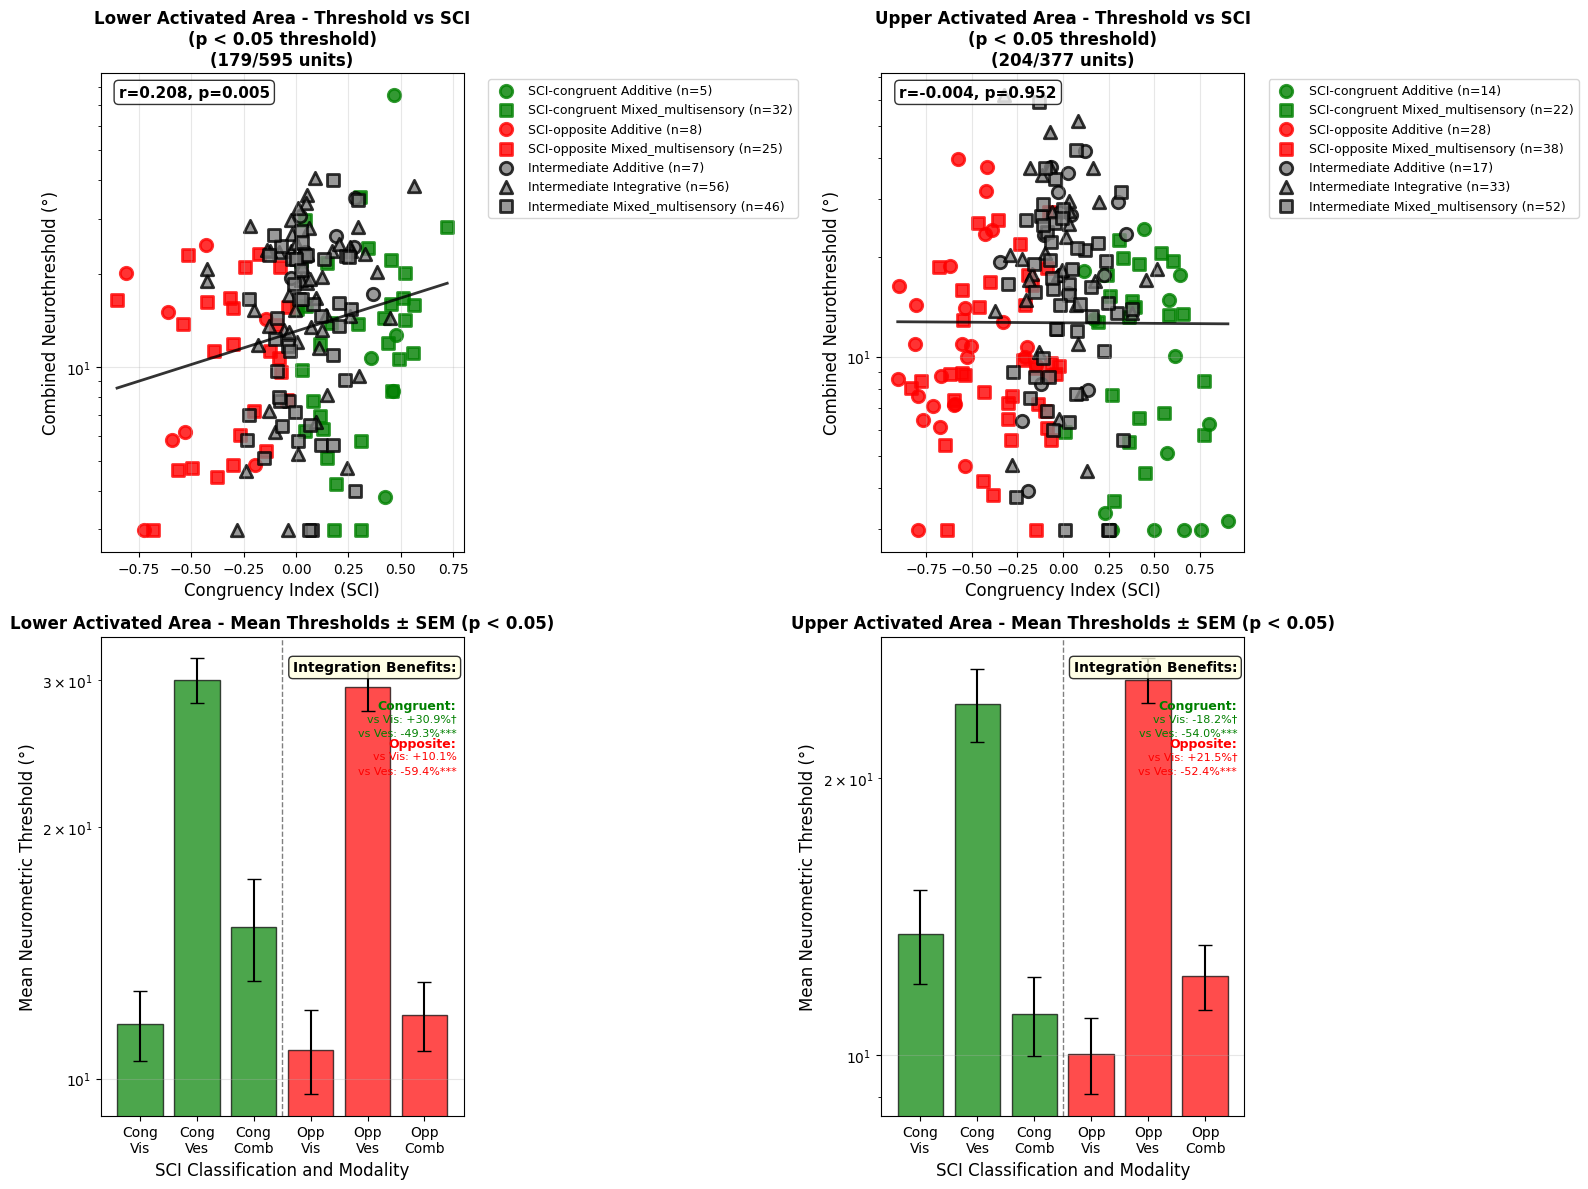

In [48]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import pearsonr, ttest_ind, ttest_rel, chi2

def analyze_all_units_by_sci(tuning_file):
    """
    Analyze multisensory units classified by SCI with Fisher's method and refined selectivity criteria
    """
    # Load and filter data
    tuning_df = pd.read_csv(tuning_file)
    areas = ['MST', 'VPS']
    
    # Area name mapping for display (to avoid bias)
    area_display_names = {
        'MST': 'Lower Activated Area',
        'VPS': 'Upper Activated Area'
    }
    
    # Filter for multisensory units using refined criteria
    multisensory_condition = classify_multisensory_units(tuning_df)
    tuning_filtered = tuning_df[multisensory_condition].copy()
    
    print(f"Total units: {len(tuning_df)}")
    print(f"Multisensory units: {len(tuning_filtered)}")
    
    # Print breakdown of multisensory types
    print_multisensory_breakdown(tuning_filtered)
    
    if len(tuning_filtered) == 0:
        print("No units pass multisensory criteria")
        return tuning_df
    
    # Calculate and classify SCI using Fisher's method
    tuning_filtered = calculate_and_classify_sci_fisher(tuning_filtered)
    
    # Print SCI distribution
    sci_counts = tuning_filtered['SCI_classification'].value_counts()
    print(f"\nSCI Distribution (Fisher's Method):")
    for classification, count in sci_counts.items():
        print(f"  {classification}: {count} ({count/len(tuning_filtered)*100:.1f}%)")
    
    # Create plots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    for area_idx, area in enumerate(areas):
        area_data = tuning_filtered[tuning_filtered['area'] == area].copy()
        total_area = len(tuning_df[tuning_df['area'] == area])
        
        # Use display name for printing and plotting
        display_name = area_display_names[area]
        print(f"\n{display_name}: {len(area_data)}/{total_area} units")
        
        # Create scatter plot
        create_scatter_plot(axes[0, area_idx], area_data, display_name, len(area_data), total_area)
        
        # Create bar plot with integration statistics
        create_bar_plot_with_integration_stats(axes[1, area_idx], area_data, display_name)
    
    plt.tight_layout()
    plt.show()
    
    return tuning_filtered

def classify_multisensory_units(tuning_df):
    """
    Classify multisensory units using refined criteria with threshold = 0.05
    """
    # Add multisensory type classification to dataframe
    tuning_df['multisensory_type'] = 'None'
    
    multisensory_mask = []
    threshold = 0.05  # Your specified threshold
    
    for idx, row in tuning_df.iterrows():
        # Apply your selectivity definitions
        vis_selective = row['vis_pval'] < threshold and row['ves_pval'] > threshold
        ves_selective = row['ves_pval'] < threshold and row['vis_pval'] > threshold
        comb_selective = (row['vis_pval'] < threshold and row['ves_pval'] < threshold) or row['comb_pval'] < threshold
        
        # Determine unit type based on selectivity patterns
        if vis_selective and not ves_selective and not comb_selective:
            tuning_df.loc[idx, 'multisensory_type'] = 'Visual_only'
            multisensory_mask.append(False)
        elif ves_selective and not vis_selective and not comb_selective:
            tuning_df.loc[idx, 'multisensory_type'] = 'Vestibular_only'
            multisensory_mask.append(False)
        elif comb_selective:
            # Further classify multisensory units
            additive_multisensory = row['vis_pval'] < threshold and row['ves_pval'] < threshold
            integrative_multisensory = (row['comb_pval'] < threshold and 
                                       row['vis_pval'] > threshold and 
                                       row['ves_pval'] > threshold)
            
            if additive_multisensory:
                tuning_df.loc[idx, 'multisensory_type'] = 'Additive'
                multisensory_mask.append(True)
            elif integrative_multisensory:
                tuning_df.loc[idx, 'multisensory_type'] = 'Integrative'
                multisensory_mask.append(True)
            else:
                # This covers cases where comb_selective is True due to comb_pval < threshold
                # but doesn't fit purely additive or integrative patterns
                tuning_df.loc[idx, 'multisensory_type'] = 'Mixed_multisensory'
                multisensory_mask.append(True)
        else:
            tuning_df.loc[idx, 'multisensory_type'] = 'Non_responsive'
            multisensory_mask.append(False)
    
    return np.array(multisensory_mask)

def print_multisensory_breakdown(tuning_filtered):
    """Print breakdown of multisensory unit types"""
    if 'multisensory_type' in tuning_filtered.columns:
        ms_counts = tuning_filtered['multisensory_type'].value_counts()
        print(f"\nMultisensory Unit Types (threshold = 0.05):")
        for ms_type, count in ms_counts.items():
            print(f"  {ms_type}: {count} ({count/len(tuning_filtered)*100:.1f}%)")

def calculate_and_classify_sci_fisher(tuning_filtered):
    """Calculate SCI and classify units using Fisher's combined probability test"""
    # Calculate SCI
    if 'vis_corr_r' in tuning_filtered.columns and 'ves_corr_r' in tuning_filtered.columns:
        vis_corr = tuning_filtered['vis_corr_r'].fillna(0)
        ves_corr = tuning_filtered['ves_corr_r'].fillna(0)
        tuning_filtered['SCI'] = vis_corr * ves_corr
    else:
        tuning_filtered['SCI'] = np.random.uniform(-1, 1, len(tuning_filtered))
        print("Warning: Using random SCI values")
    
    # Initialize all as intermediate
    tuning_filtered['SCI_classification'] = 'Intermediate'
    
    # Classify based on Fisher's combined probability test
    for idx, row in tuning_filtered.iterrows():
        sci_value = row['SCI']
        
        if not np.isnan(sci_value):
            vis_p = row.get('vis_corr_p', 1.0)
            ves_p = row.get('ves_corr_p', 1.0)
            
            # For integrative multisensory units, we might not have individual correlations
            # In that case, use a different approach
            if row.get('multisensory_type') == 'Integrative':
                # For integrative units, check if combined correlation exists
                comb_p = row.get('comb_corr_p', 1.0)
                if pd.notna(comb_p) and comb_p < 0.05:
                    # Use combined correlation sign to determine congruency
                    comb_r = row.get('comb_corr_r', 0)
                    if comb_r > 0:
                        tuning_filtered.loc[idx, 'SCI_classification'] = 'SCI-congruent'
                    elif comb_r < 0:
                        tuning_filtered.loc[idx, 'SCI_classification'] = 'SCI-opposite'
            else:
                # For additive and mixed multisensory units, use Fisher's test
                if (pd.notna(vis_p) and pd.notna(ves_p) and 
                    pd.notna(row.get('vis_corr_r')) and pd.notna(row.get('ves_corr_r')) and
                    vis_p > 0 and ves_p > 0):  # Avoid log(0)
                    
                    # Fisher's method: -2 * ln(p1 * p2) follows chi-square with 4 df
                    fisher_stat = -2 * (np.log(vis_p) + np.log(ves_p))
                    combined_p = 1 - chi2.cdf(fisher_stat, df=4)
                    
                    # If combined significance is < 0.05
                    if combined_p < 0.05:
                        if sci_value > 0:
                            tuning_filtered.loc[idx, 'SCI_classification'] = 'SCI-congruent'
                        else:
                            tuning_filtered.loc[idx, 'SCI_classification'] = 'SCI-opposite'
    
    return tuning_filtered

def create_scatter_plot(ax, area_data, area_name, multimodal_units, total_units):
    """Create scatter plot of SCI vs threshold with multisensory type information"""
    # Define styles - consistent with Fisher's method colors
    sci_styles = {
        'SCI-congruent': {'color': 'green', 'marker': 'o'},
        'SCI-opposite': {'color': 'red', 'marker': 's'},
        'Intermediate': {'facecolors': 'gray', 'edgecolors': 'black', 'marker': '^'}
    }
    
    # Define multisensory type markers
    ms_markers = {
        'Additive': 'o',           # Circle for additive
        'Integrative': '^',        # Triangle for integrative
        'Mixed_multisensory': 's'  # Square for mixed
    }
    
    # Filter valid data
    valid_mask = (~area_data['comb_neurometric_threshold'].isna() & 
                  ~area_data['SCI'].isna() & 
                  (area_data['comb_neurometric_threshold'] > 0))
    
    if not np.any(valid_mask):
        ax.text(0.5, 0.5, f'No valid data in {area_name}', ha='center', va='center', 
                transform=ax.transAxes, fontsize=12)
    else:
        x_sci = area_data.loc[valid_mask, 'SCI']
        y_thresh = area_data.loc[valid_mask, 'comb_neurometric_threshold']
        sci_classes = area_data.loc[valid_mask, 'SCI_classification']
        ms_types = area_data.loc[valid_mask, 'multisensory_type'] if 'multisensory_type' in area_data.columns else None
        
        # Plot each SCI class
        for classification in ['SCI-congruent', 'SCI-opposite', 'Intermediate']:
            mask = sci_classes == classification
            if np.any(mask):
                style = sci_styles[classification]
                
                # Further separate by multisensory type if available
                if ms_types is not None:
                    for ms_type in ['Additive', 'Integrative', 'Mixed_multisensory']:
                        ms_mask = mask & (ms_types == ms_type)
                        if np.any(ms_mask):
                            marker = ms_markers.get(ms_type, 'o')
                            if classification == 'Intermediate':
                                ax.scatter(x_sci[ms_mask], y_thresh[ms_mask], 
                                         facecolors=style['facecolors'], edgecolors=style['edgecolors'],
                                         marker=marker, alpha=0.8, s=80, linewidth=2,
                                         label=f'{classification} {ms_type} (n={np.sum(ms_mask)})')
                            else:
                                ax.scatter(x_sci[ms_mask], y_thresh[ms_mask], 
                                         c=style['color'], marker=marker,
                                         alpha=0.8, s=80, linewidth=2,
                                         label=f'{classification} {ms_type} (n={np.sum(ms_mask)})')
                else:
                    # Fallback if no multisensory type info
                    if classification == 'Intermediate':
                        ax.scatter(x_sci[mask], y_thresh[mask], 
                                 facecolors=style['facecolors'], edgecolors=style['edgecolors'],
                                 marker=style['marker'], alpha=0.8, s=80, linewidth=2,
                                 label=f'{classification} (n={np.sum(mask)})')
                    else:
                        ax.scatter(x_sci[mask], y_thresh[mask], 
                                 c=style['color'], marker=style['marker'],
                                 alpha=0.8, s=80, linewidth=2,
                                 label=f'{classification} (n={np.sum(mask)})')
        
        # Add trend line and correlation
        if len(x_sci) >= 3:
            z = np.polyfit(x_sci, np.log10(y_thresh), 1)
            p = np.poly1d(z)
            x_trend = np.linspace(x_sci.min(), x_sci.max(), 100)
            ax.plot(x_trend, 10**p(x_trend), "k-", alpha=0.8, linewidth=2)
            
            corr, p_val = pearsonr(x_sci, np.log10(y_thresh))
            ax.text(0.05, 0.95, f'r={corr:.3f}, p={p_val:.3f}', 
                   transform=ax.transAxes, bbox=dict(boxstyle="round,pad=0.3", 
                   facecolor="white", alpha=0.8), fontsize=11, fontweight='bold')
    
    # Format plot
    ax.set_yscale('log')
    ax.set_xlabel('Congruency Index (SCI)', fontsize=12)
    ax.set_ylabel('Combined Neurothreshold (°)', fontsize=12)
    ax.set_title(f'{area_name} - Threshold vs SCI\n(p < 0.05 threshold)\n({multimodal_units}/{total_units} units)', 
                fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')

def create_bar_plot_with_integration_stats(ax, area_data, area_name):
    """Create bar plot and add integration benefit statistics as text"""
    # Filter for significant SCI cells using Fisher's method
    significant_cells = area_data[area_data['SCI_classification'].isin(['SCI-congruent', 'SCI-opposite'])].copy()
    
    if len(significant_cells) == 0:
        ax.text(0.5, 0.5, f'No Fisher-significant SCI cells in {area_name}', 
               ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_ylabel('Mean Neurometric Threshold (°)', fontsize=12)
        ax.set_title(f'{area_name} - Mean Thresholds ± SEM', fontsize=12, fontweight='bold')
        return
    
    # Prepare bar plot data
    modalities = ['Visual', 'Vestibular', 'Combined']
    thresh_cols = ['vis_neurometric_threshold', 'ves_neurometric_threshold', 'comb_neurometric_threshold']
    
    x_positions, means, sems, colors, labels = [], [], [], [], []
    
    for i, sci_class in enumerate(['SCI-congruent', 'SCI-opposite']):
        class_data = significant_cells[significant_cells['SCI_classification'] == sci_class]
        for j, (modality, thresh_col) in enumerate(zip(modalities, thresh_cols)):
            thresh_values = class_data[thresh_col].dropna()
            if len(thresh_values) > 0:
                pos = i * 3 + j + 1
                x_positions.append(pos)
                means.append(np.mean(thresh_values))
                sems.append(np.std(thresh_values, ddof=1) / np.sqrt(len(thresh_values)))
                colors.append('green' if sci_class == 'SCI-congruent' else 'red')
                
                mod_short = {'Visual': 'Vis', 'Vestibular': 'Ves', 'Combined': 'Comb'}[modality]
                sci_short = 'Cong' if sci_class == 'SCI-congruent' else 'Opp'
                labels.append(f'{sci_short}\n{mod_short}')
    
    if x_positions:
        # Create bar plot
        ax.bar(x_positions, means, yerr=sems, color=colors, alpha=0.7, 
               capsize=5, edgecolor='black', linewidth=1)
        ax.axvline(x=3.5, color='black', linestyle='--', alpha=0.5, linewidth=1)
        
        # Format plot
        ax.set_yscale('log')
        ax.set_ylabel('Mean Neurometric Threshold (°)', fontsize=12)
        ax.set_xlabel('SCI Classification and Modality', fontsize=12)
        ax.set_title(f'{area_name} - Mean Thresholds ± SEM (p < 0.05)', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_xticks(x_positions)
        ax.set_xticklabels(labels, fontsize=10)
        
        # Add integration benefit statistics as text
        add_integration_stats_to_plot(ax, significant_cells)
    
    # Run statistical analyses (print to console) - use original area name for console output
    original_area = 'MST' if 'Lower' in area_name else 'VPS'
    run_statistical_analyses(significant_cells, original_area)

def add_integration_stats_to_plot(ax, significant_cells):
    """Add integration benefit statistics as text on the plot"""
    # Calculate integration benefits for both SCI classes
    integration_stats = []
    
    for sci_class in ['SCI-congruent', 'SCI-opposite']:
        class_data = significant_cells[significant_cells['SCI_classification'] == sci_class]
        if len(class_data) < 3:
            continue
        
        class_stats = {'class': sci_class, 'stats': []}
        
        # vs Visual (only for additive and mixed multisensory units)
        testable_data = class_data[class_data.get('multisensory_type', 'Additive').isin(['Additive', 'Mixed_multisensory'])]
        if len(testable_data) > 2:
            vis_benefit = calculate_integration_benefit(testable_data, 'vis_neurometric_threshold')
            if vis_benefit:
                class_stats['stats'].append(f"vs Vis: {vis_benefit['change']:+.1f}%{vis_benefit['sig']}")
            
            # vs Vestibular
            ves_benefit = calculate_integration_benefit(testable_data, 'ves_neurometric_threshold')
            if ves_benefit:
                class_stats['stats'].append(f"vs Ves: {ves_benefit['change']:+.1f}%{ves_benefit['sig']}")
        
        if class_stats['stats']:
            integration_stats.append(class_stats)
    
    # Add text to plot
    if integration_stats:
        # Position text in upper right area
        y_start = 0.95
        x_pos = 0.98
        
        ax.text(x_pos, y_start, 'Integration Benefits:', 
               transform=ax.transAxes, fontsize=10, fontweight='bold',
               ha='right', va='top',
               bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))
        
        y_offset = 0.08
        for i, stat_group in enumerate(integration_stats):
            y_pos = y_start - (i + 1) * y_offset
            
            # Class name - updated colors to match Fisher's method
            color = 'green' if stat_group['class'] == 'SCI-congruent' else 'red'
            class_short = 'Congruent' if stat_group['class'] == 'SCI-congruent' else 'Opposite'
            
            ax.text(x_pos, y_pos, f"{class_short}:", 
                   transform=ax.transAxes, fontsize=9, fontweight='bold',
                   ha='right', va='top', color=color)
            
            # Stats
            for j, stat_text in enumerate(stat_group['stats']):
                stat_y = y_pos - (j + 1) * 0.03
                ax.text(x_pos, stat_y, f"  {stat_text}", 
                       transform=ax.transAxes, fontsize=8,
                       ha='right', va='top', color=color)

def calculate_integration_benefit(class_data, single_col):
    """Calculate integration benefit for a specific single modality"""
    # Find units with both single and combined data
    paired_units = class_data.dropna(subset=[single_col, 'comb_neurometric_threshold']).index
    
    if len(paired_units) > 2:
        single_vals = class_data.loc[paired_units, single_col]
        comb_vals = class_data.loc[paired_units, 'comb_neurometric_threshold']
        
        t_stat, p_val = ttest_rel(comb_vals, single_vals)
        change = ((np.mean(comb_vals) - np.mean(single_vals)) / np.mean(single_vals)) * 100
        sig = get_significance_marker(p_val)
        
        return {
            'change': change,
            'p_val': p_val,
            'sig': sig,
            'n': len(paired_units)
        }
    
    return None

def run_statistical_analyses(significant_cells, area):
    """Run all statistical comparisons"""
    print(f"\n{area} Statistical Analysis (p < 0.05 + Fisher's Method):")
    
    # Print multisensory type breakdown
    if 'multisensory_type' in significant_cells.columns:
        ms_counts = significant_cells['multisensory_type'].value_counts()
        print("  Multisensory types in significant SCI cells:")
        for ms_type, count in ms_counts.items():
            print(f"    {ms_type}: {count}")
    
    # 1. Between SCI classes comparison
    print("  Between SCI classes:")
    modality_cols = {
        'Visual': 'vis_neurometric_threshold',
        'Vestibular': 'ves_neurometric_threshold', 
        'Combined': 'comb_neurometric_threshold'
    }
    
    for modality, col in modality_cols.items():
        cong_data = significant_cells[significant_cells['SCI_classification'] == 'SCI-congruent'][col].dropna()
        opp_data = significant_cells[significant_cells['SCI_classification'] == 'SCI-opposite'][col].dropna()
        
        if len(cong_data) > 1 and len(opp_data) > 1:
            t_stat, p_val = ttest_ind(cong_data, opp_data)
            sig = get_significance_marker(p_val)
            print(f"    {modality}: Cong={np.mean(cong_data):.1f}° vs Opp={np.mean(opp_data):.1f}°, p={p_val:.4f}{sig}")
    
    # 2. Integration benefits analysis (for additive and mixed multisensory)
    print("  Integration benefits (Combined vs Single, Additive+Mixed MS only):")
    
    for sci_class in ['SCI-congruent', 'SCI-opposite']:
        class_data = significant_cells[significant_cells['SCI_classification'] == sci_class]
        testable_data = class_data[class_data.get('multisensory_type', 'Additive').isin(['Additive', 'Mixed_multisensory'])]
        
        if len(testable_data) < 3:
            continue
        
        print(f"    {sci_class} (n={len(testable_data)}):")
        
        # Combined vs Visual
        analyze_integration_benefit(testable_data, 'vis_neurometric_threshold', 'Visual')
        
        # Combined vs Vestibular
        analyze_integration_benefit(testable_data, 'ves_neurometric_threshold', 'Vestibular')

def analyze_integration_benefit(class_data, single_col, modality_name):
    """Analyze integration benefit for a specific single modality"""
    # Find units with both single and combined data
    paired_units = class_data.dropna(subset=[single_col, 'comb_neurometric_threshold']).index
    
    if len(paired_units) > 2:
        single_vals = class_data.loc[paired_units, single_col]
        comb_vals = class_data.loc[paired_units, 'comb_neurometric_threshold']
        
        t_stat, p_val = ttest_rel(comb_vals, single_vals)
        change = ((np.mean(comb_vals) - np.mean(single_vals)) / np.mean(single_vals)) * 100
        sig = get_significance_marker(p_val)
        
        print(f"      vs {modality_name}: {change:+.1f}% ({'better' if change < 0 else 'worse'}), "
              f"p={p_val:.4f}{sig} (n={len(paired_units)})")

def get_significance_marker(p_val):
    """Get significance marker for p-value"""
    if p_val < 0.001:
        return "***"
    elif p_val < 0.01:
        return "**"
    elif p_val < 0.05:
        return "*"
    elif p_val < 0.1:
        return "†"
    else:
        return ""

# Usage
tuning_file = r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMPtuning_neuralfeatures\zarya_pooled_neural_features_tuning_stimOn.csv'
results = analyze_all_units_by_sci(tuning_file)

In [13]:
df = pd.read_csv(r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMPtuning_neuralfeatures\zarya_pooled_neural_features_tuning_stimOn.csv')


In [14]:
df.keys()

Index(['subject', 'date', 'alignment', 'is_tuning', 'unit_idx', 'area',
       'absolute_x', 'absolute_y', 'relative_x', 'relative_y',
       'absolute_depth', 'relative_depth', 'overall_firing_rate',
       'ves_selective', 'ves_pval', 'vis_selective', 'vis_pval',
       'comb_selective', 'comb_pval', 'ves_corr_r', 'ves_corr_p', 'vis_corr_r',
       'vis_corr_p', 'ves_neurometric_threshold', 'ves_neurometric_r2',
       'ves_neurometric_mu', 'ves_neurometric_sigma',
       'vis_neurometric_threshold', 'vis_neurometric_r2', 'vis_neurometric_mu',
       'vis_neurometric_sigma', 'comb_neurometric_threshold',
       'comb_neurometric_r2', 'comb_neurometric_mu', 'comb_neurometric_sigma',
       'ves_best_window_idx', 'vis_best_window_idx', 'comb_best_window_idx'],
      dtype='object')

### Congruency vs neurometric threshold

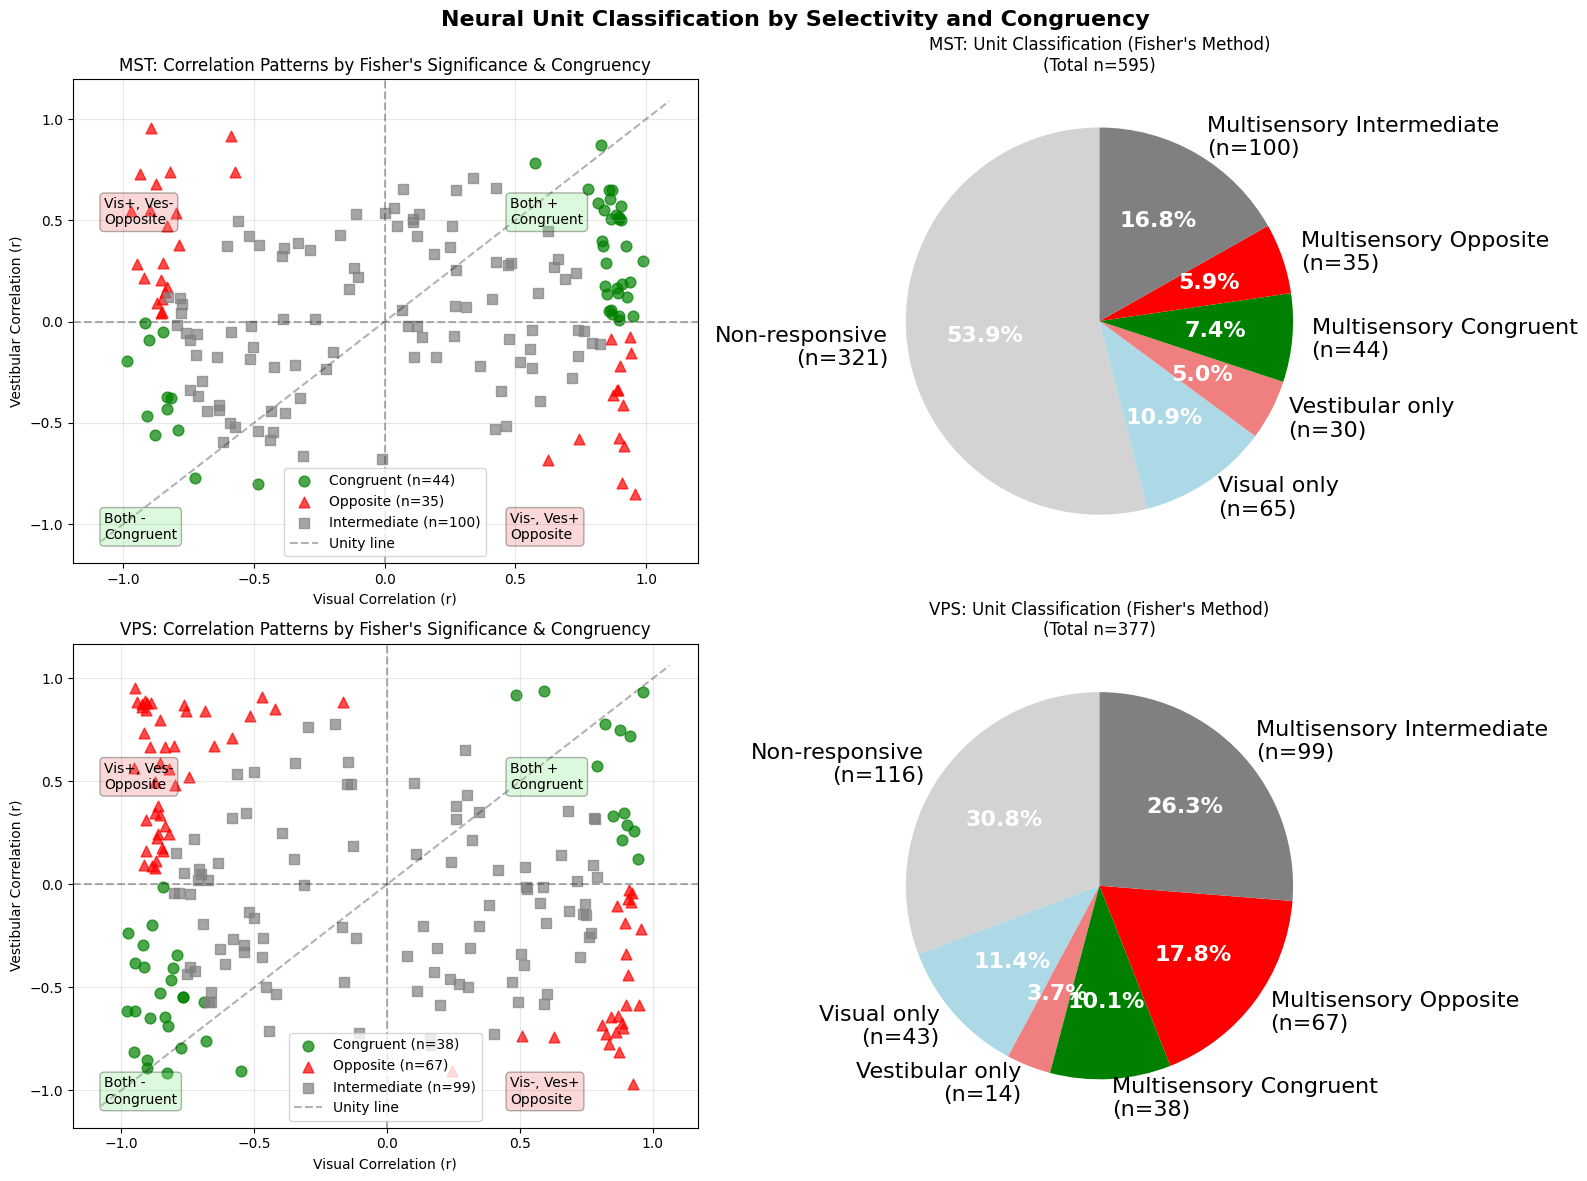


DETAILED CLASSIFICATION STATISTICS (Fisher's Method)

MST AREA (Total n=595):
----------------------------------------
  Non-responsive      : 321 units ( 53.9%)
  Visual only         :  65 units ( 10.9%)
  Vestibular only     :  30 units (  5.0%)
  Multisensory Congruent:  44 units (  7.4%)
  Multisensory Opposite:  35 units (  5.9%)
  Multisensory Intermediate: 100 units ( 16.8%)

  Multisensory Summary:
    Total multisensory: 179 (30.1%)
    Congruent vs Opposite ratio: 44:35
    Congruent proportion: 55.7%
    SCI statistics:
      Mean SCI: 0.026
      Std SCI: 0.279
      Positive SCI: 103/179 (57.5%)

VPS AREA (Total n=377):
----------------------------------------
  Non-responsive      : 116 units ( 30.8%)
  Visual only         :  43 units ( 11.4%)
  Vestibular only     :  14 units (  3.7%)
  Multisensory Congruent:  38 units ( 10.1%)
  Multisensory Opposite:  67 units ( 17.8%)
  Multisensory Intermediate:  99 units ( 26.3%)

  Multisensory Summary:
    Total multisensory: 20

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import chi2
import seaborn as sns

# Load the data
df = pd.read_csv(r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMPtuning_neuralfeatures\zarya_pooled_neural_features_tuning_stimOn.csv')

# Define comprehensive categories based on selectivity and congruency with Fisher's method
def classify_unit_comprehensive(row):
    threshold = 0.05
    vis_selective = row['vis_pval'] < threshold and row['ves_pval'] > threshold
    ves_selective = row['ves_pval'] < threshold and row['vis_pval'] > threshold
    comb_selective = (row['vis_pval'] < threshold and row['ves_pval'] < threshold) or row['comb_pval'] < threshold
    
    # If not selective for any modality
    if not (vis_selective or ves_selective or comb_selective):
        return 'Non-responsive'
    
    # If only selective for one modality
    if vis_selective and not ves_selective and not comb_selective:
        return 'Visual only'
    
    if ves_selective and not vis_selective and not comb_selective:
        return 'Vestibular only'
    
    # If selective for multiple modalities (multisensory)
    if vis_selective or ves_selective or comb_selective:
        # Check if correlations exist and use Fisher's method for significance
        vis_p = row.get('vis_corr_p', 1.0)
        ves_p = row.get('ves_corr_p', 1.0)
        
        # Check if both correlations exist and are valid
        if (pd.notna(vis_p) and pd.notna(ves_p) and 
            pd.notna(row.get('vis_corr_r')) and pd.notna(row.get('ves_corr_r')) and
            vis_p > 0 and ves_p > 0):  # Avoid log(0)
            
            # Fisher's method: -2 * ln(p1 * p2) follows chi-square with 4 df
            fisher_stat = -2 * (np.log(vis_p) + np.log(ves_p))
            combined_p = 1 - chi2.cdf(fisher_stat, df=4)
            
            # If combined significance is < 0.05
            if combined_p < 0.05:
                vis_positive = row['vis_corr_r'] > 0
                ves_positive = row['ves_corr_r'] > 0
                
                if vis_positive == ves_positive:
                    return 'Multisensory Congruent'
                else:
                    return 'Multisensory Opposite'
            else:
                return 'Multisensory Intermediate'
        else:
            return 'Multisensory Intermediate'
    
    return 'Other'

# Apply classification
df['unit_category'] = df.apply(classify_unit_comprehensive, axis=1)

# Calculate SCI for analysis
if 'vis_corr_r' in df.columns and 'ves_corr_r' in df.columns:
    vis_corr = df['vis_corr_r'].fillna(0)
    ves_corr = df['ves_corr_r'].fillna(0)
    df['SCI'] = vis_corr * ves_corr

# Define colors for each category
category_colors = {
    'Non-responsive': 'lightgray',
    'Visual only': 'lightblue', 
    'Vestibular only': 'lightcoral',
    'Multisensory Congruent': 'green',
    'Multisensory Opposite': 'red',
    'Multisensory Intermediate': 'gray'
}

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Neural Unit Classification by Selectivity and Congruency', fontsize=16, fontweight='bold')

areas = ['MST', 'VPS']

for i, area in enumerate(areas):
    area_data = df[df['area'] == area]
    
    # SUBPLOT 1: Scatter plot of vis_corr_r vs ves_corr_r with significance-based coloring
    ax1 = axes[i, 0]
    
    # Get data with correlation values
    corr_data = area_data.dropna(subset=['vis_corr_r', 'ves_corr_r'])
    
    if len(corr_data) > 0:
        # Separate by category
        for category in ['Multisensory Congruent', 'Multisensory Opposite', 'Multisensory Intermediate']:
            cat_data = corr_data[corr_data['unit_category'] == category]
            if len(cat_data) > 0:
                marker = 'o' if 'Congruent' in category else ('^' if 'Opposite' in category else 's')
                ax1.scatter(cat_data['vis_corr_r'], cat_data['ves_corr_r'], 
                           alpha=0.7, s=60, color=category_colors[category], 
                           marker=marker, label=f'{category.replace("Multisensory ", "")} (n={len(cat_data)})')
        
        # Add reference lines
        ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)
        ax1.axvline(x=0, color='k', linestyle='--', alpha=0.3)
        
        # Add unity line
        lim_min = min(ax1.get_xlim()[0], ax1.get_ylim()[0])
        lim_max = max(ax1.get_xlim()[1], ax1.get_ylim()[1])
        ax1.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', alpha=0.3, label='Unity line')
        
        ax1.set_xlabel('Visual Correlation (r)')
        ax1.set_ylabel('Vestibular Correlation (r)')
        ax1.set_title(f'{area}: Correlation Patterns by Fisher\'s Significance & Congruency')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Add significance regions
        ax1.text(0.7, 0.7, 'Both +\nCongruent', transform=ax1.transAxes, 
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))
        ax1.text(0.05, 0.7, 'Vis+, Ves-\nOpposite', transform=ax1.transAxes,
                bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.3))
        ax1.text(0.7, 0.05, 'Vis-, Ves+\nOpposite', transform=ax1.transAxes,
                bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.3))
        ax1.text(0.05, 0.05, 'Both -\nCongruent', transform=ax1.transAxes,
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))
    else:
        ax1.text(0.5, 0.5, 'No correlation data available', ha='center', va='center', transform=ax1.transAxes)
        ax1.set_title(f'{area}: Correlation Patterns')
    
    # SUBPLOT 2: Pie chart of unit categories
    ax2 = axes[i, 1]
    
    # Count units in each category
    category_counts = area_data['unit_category'].value_counts()
    
    # Ensure all categories are represented (even if count is 0)
    all_categories = ['Non-responsive', 'Visual only', 'Vestibular only', 
                     'Multisensory Congruent', 'Multisensory Opposite', 'Multisensory Intermediate']
    
    counts = []
    labels = []
    colors = []
    
    for cat in all_categories:
        count = category_counts.get(cat, 0)
        if count > 0:  # Only include categories with non-zero counts
            counts.append(count)
            labels.append(f'{cat}\n(n={count})')
            colors.append(category_colors[cat])
    
    if len(counts) > 0:
        wedges, texts, autotexts = ax2.pie(counts, labels=labels, colors=colors, autopct='%1.1f%%',
                                          startangle=90, textprops={'fontsize': 16})
        
        # Make percentage text bold
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontweight('bold')
    
    ax2.set_title(f'{area}: Unit Classification (Fisher\'s Method)\n(Total n={len(area_data)})')

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\n" + "="*60)
print("DETAILED CLASSIFICATION STATISTICS (Fisher's Method)")
print("="*60)

for area in areas:
    area_data = df[df['area'] == area]
    
    print(f"\n{area} AREA (Total n={len(area_data)}):")
    print("-" * 40)
    
    category_counts = area_data['unit_category'].value_counts()
    
    for category in ['Non-responsive', 'Visual only', 'Vestibular only', 
                     'Multisensory Congruent', 'Multisensory Opposite', 'Multisensory Intermediate']:
        count = category_counts.get(category, 0)
        percentage = (count / len(area_data)) * 100 if len(area_data) > 0 else 0
        print(f"  {category:20s}: {count:3d} units ({percentage:5.1f}%)")
    
    # Additional statistics for multisensory units
    multisensory_data = area_data[area_data['unit_category'].str.contains('Multisensory')]
    if len(multisensory_data) > 0:
        print(f"\n  Multisensory Summary:")
        print(f"    Total multisensory: {len(multisensory_data)} ({len(multisensory_data)/len(area_data)*100:.1f}%)")
        
        congruent = len(area_data[area_data['unit_category'] == 'Multisensory Congruent'])
        opposite = len(area_data[area_data['unit_category'] == 'Multisensory Opposite'])
        intermediate = len(area_data[area_data['unit_category'] == 'Multisensory Intermediate'])
        
        if congruent + opposite > 0:
            print(f"    Congruent vs Opposite ratio: {congruent}:{opposite}")
            print(f"    Congruent proportion: {congruent/(congruent+opposite)*100:.1f}%")
        
        # SCI statistics for multisensory units
        if 'SCI' in area_data.columns:
            ms_sci = multisensory_data['SCI'].dropna()
            if len(ms_sci) > 0:
                print(f"    SCI statistics:")
                print(f"      Mean SCI: {np.mean(ms_sci):.3f}")
                print(f"      Std SCI: {np.std(ms_sci):.3f}")
                print(f"      Positive SCI: {np.sum(ms_sci > 0)}/{len(ms_sci)} ({np.sum(ms_sci > 0)/len(ms_sci)*100:.1f}%)")

# Overall summary
print(f"\n" + "="*60)
print("OVERALL SUMMARY (Fisher's Method)")
print("="*60)

overall_counts = df['unit_category'].value_counts()
total_units = len(df)

for category in ['Non-responsive', 'Visual only', 'Vestibular only', 
                 'Multisensory Congruent', 'Multisensory Opposite', 'Multisensory Intermediate']:
    count = overall_counts.get(category, 0)
    percentage = (count / total_units) * 100 if total_units > 0 else 0
    print(f"{category:20s}: {count:3d} units ({percentage:5.1f}%)")

# Multisensory congruency analysis
multisensory_total = len(df[df['unit_category'].str.contains('Multisensory')])
congruent_total = len(df[df['unit_category'] == 'Multisensory Congruent'])
opposite_total = len(df[df['unit_category'] == 'Multisensory Opposite'])

if congruent_total + opposite_total > 0:
    print(f"\nMultisensory Congruency Analysis (Fisher's Method):")
    print(f"  Total with defined congruency: {congruent_total + opposite_total}")
    print(f"  Congruent: {congruent_total} ({congruent_total/(congruent_total+opposite_total)*100:.1f}%)")
    print(f"  Opposite: {opposite_total} ({opposite_total/(congruent_total+opposite_total)*100:.1f}%)")

# Additional Fisher's method statistics
print(f"\nFisher's Method Statistics:")
fisher_significant = len(df[(df['unit_category'] == 'Multisensory Congruent') | 
                           (df['unit_category'] == 'Multisensory Opposite')])
fisher_total = len(df[df['unit_category'].str.contains('Multisensory')])

if fisher_total > 0:
    print(f"  Units with Fisher's p < 0.05: {fisher_significant}/{fisher_total} ({fisher_significant/fisher_total*100:.1f}%)")

# SCI distribution analysis
if 'SCI' in df.columns:
    sci_data = df['SCI'].dropna()
    if len(sci_data) > 0:
        print(f"\nSCI Distribution:")
        print(f"  Total units with SCI: {len(sci_data)}")
        print(f"  Mean SCI: {np.mean(sci_data):.3f}")
        print(f"  Median SCI: {np.median(sci_data):.3f}")
        print(f"  Positive SCI: {np.sum(sci_data > 0)}/{len(sci_data)} ({np.sum(sci_data > 0)/len(sci_data)*100:.1f}%)")
        print(f"  Negative SCI: {np.sum(sci_data < 0)}/{len(sci_data)} ({np.sum(sci_data < 0)/len(sci_data)*100:.1f}%)")

In [60]:
print(df)

    subject      date alignment  is_tuning  unit_idx area  absolute_x  \
0     zarya  20250417    stimOn       True         0  MST           4   
1     zarya  20250417    stimOn       True         1  MST           4   
2     zarya  20250417    stimOn       True         2  MST           4   
3     zarya  20250417    stimOn       True         3  MST           4   
4     zarya  20250417    stimOn       True         4  MST           4   
..      ...       ...       ...        ...       ...  ...         ...   
967   zarya  20250710    stimOn       True       181  VPS           5   
968   zarya  20250710    stimOn       True       182  VPS           5   
969   zarya  20250710    stimOn       True       183  VPS           5   
970   zarya  20250710    stimOn       True       184  VPS           5   
971   zarya  20250710    stimOn       True       185  VPS           5   

     absolute_y  relative_x  relative_y  ...  vis_neurometric_sigma  \
0             3           0          -1  ...        